In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HF_NEW")
assert hf_token, "Set HF_TOKEN (or HF_NEW) in your .env file at the repo root"


In [2]:
from datasets import load_dataset
LOAD_SPECIFIC_FILE = True
dataset_name = "1024m/LID"
if LOAD_SPECIFIC_FILE:
    file_path = "Data_Hackathon/LID-20000.parquet"
    dataset = load_dataset("parquet", data_files={"train": f"hf://datasets/{dataset_name}/{file_path}"}, token=hf_token)["train"]
else:
    dataset = load_dataset(dataset_name, token=hf_token)["train"]
print(f"dataset  : {dataset_name}")
print(f"samples  : {len(dataset)}")
print(f"columns  : {dataset.column_names}")
print(f"size     : {dataset.dataset_size / 1024**2:.3f} MB")

dataset  : 1024m/LID
samples  : 1248835
columns  : ['lang', 'text', 'source', 'ISO-693-3']
size     : 7336.965 MB


In [3]:
df_data = dataset.to_pandas()
df_data

,lang,text,source,ISO-693-3
0,german,\n\nEreignisse\n\nPolitik und Weltgeschehen\n\...,WIKIPEDIA,deu
1,lithuanian,Upiniai delfinai (Platanistidae) – banginių (C...,WIKIPEDIA,lit
2,yoruba,je onimo sayensi to gba Ebun Nobel fun Iwosan....,WIKIPEDIA,yor
3,vietnamese,Danh sách này bao gồm các thành phố thuộc về t...,WIKIPEDIA,vie
4,galician,Corporacións democráticas en Boqueixón desde a...,WIKIPEDIA,glg
...,...,...,...,...
1248830,polish,"Prędkościomierz (ang. airspeed indicator, ASI)...",WIKIPEDIA,pol
1248831,burmese,Bayonet Neill Concelman connector (သို့မဟုပ်) ...,WIKIPEDIA,mya
1248832,galician,"Black Sabbath é unha banda inglesa, unha das f...",WIKIPEDIA,glg
1248833,maltese,"Carmel Bonavia (Żabbar, 17 ta' Lulju 1929 – 4 ...",WIKIPEDIA,mlt


In [4]:
# `unicodeblock` is included in the base `uv sync` dependency set. From
# the repo root, run:
#     uv sync
# Then launch: jupyter lab


In [5]:
from unicodeblock import blocks
blocks.of('א')  # returns 'HEBREW'

'HEBREW'

In [6]:
from unicodeblock import blocks
from collections import Counter
import numpy as np
from tqdm import tqdm
BATCH_SIZE = 10000
texts = df_data['text'].values
results = np.empty(len(texts), dtype=object)
for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    for j, text in enumerate(batch):
        results[i+j] = Counter(blocks.of(c) for c in str(text) if c.strip())
df_data['block_dist'] = results

  0%|          | 0/125 [00:00<?, ?it/s]

100%|██████████| 125/125 [28:45<00:00, 13.80s/it]


In [7]:
from huggingface_hub import login
from datasets import load_dataset
from unicodeblock import blocks
from collections import Counter
from tqdm import tqdm
import numpy as np

# hf_token is loaded from .env in cell 0.
login(token=hf_token)
ds = load_dataset("commoncrawl/CommonLID", split="test")
df_commonLID = ds.to_pandas()
texts = df_commonLID['text'].values
block_dists = np.empty(len(texts), dtype=object)
for i in tqdm(range(0, len(texts), 10000)):
    batch = texts[i:i+10000]
    for j, text in enumerate(batch):
        block_dists[i+j] = Counter(blocks.of(c) for c in str(text) if c.strip())
df_commonLID['block_dist'] = block_dists


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
100%|██████████| 38/38 [00:30<00:00,  1.24it/s]


In [8]:
df_data

,lang,text,source,ISO-693-3,block_dist
0,german,\n\nEreignisse\n\nPolitik und Weltgeschehen\n\...,WIKIPEDIA,deu,"{'BASIC_LATIN': 1559, 'LATIN_EXTENDED_LETTER':..."
1,lithuanian,Upiniai delfinai (Platanistidae) – banginių (C...,WIKIPEDIA,lit,"{'BASIC_LATIN': 432, 'BASIC_PUNCTUATION': 27, ..."
2,yoruba,je onimo sayensi to gba Ebun Nobel fun Iwosan....,WIKIPEDIA,yor,"{'BASIC_LATIN': 59, 'BASIC_PUNCTUATION': 1, 'L..."
3,vietnamese,Danh sách này bao gồm các thành phố thuộc về t...,WIKIPEDIA,vie,"{'BASIC_LATIN': 2592, 'LATIN_EXTENDED_LETTER':..."
4,galician,Corporacións democráticas en Boqueixón desde a...,WIKIPEDIA,glg,"{'BASIC_LATIN': 911, 'LATIN_EXTENDED_LETTER': ..."
...,...,...,...,...,...
1248830,polish,"Prędkościomierz (ang. airspeed indicator, ASI)...",WIKIPEDIA,pol,"{'BASIC_LATIN': 1449, 'LATIN_EXTENDED_A': 122,..."
1248831,burmese,Bayonet Neill Concelman connector (သို့မဟုပ်) ...,WIKIPEDIA,mya,"{'BASIC_LATIN': 145, 'BASIC_PUNCTUATION': 11, ..."
1248832,galician,"Black Sabbath é unha banda inglesa, unha das f...",WIKIPEDIA,glg,"{'BASIC_LATIN': 6932, 'LATIN_EXTENDED_LETTER':..."
1248833,maltese,"Carmel Bonavia (Żabbar, 17 ta' Lulju 1929 – 4 ...",WIKIPEDIA,mlt,"{'BASIC_LATIN': 1948, 'BASIC_PUNCTUATION': 156..."


In [9]:
for code in df_data['ISO-693-3'].unique():
    exec(f"df_{code} = df_data[df_data['ISO-693-3'] == '{code}'].reset_index(drop=True)")

In [10]:
for code in df_data['ISO-693-3'].unique():
    exec(f"""
df_{code}['COMM'] = df_{code}['block_dist'].apply(lambda d: max(d, key=d.get) if d else None)
df_{code}['THRESH'] = df_{code}.apply(lambda r: float(f"{{r['block_dist'].get(r['COMM'], 0) / sum(r['block_dist'].values()):.2f}}") if r['block_dist'] else None, axis=1)
""")

In [11]:
all_blocks = set()
for d in df_data['block_dist']:
    if d is not None:
        all_blocks.update(k for k in d.keys() if k is not None)
print(sorted(all_blocks))

['ALCHEMICAL_SYMBOLS', 'ALPHABETIC_PRESENTATION_FORMS', 'ANCIENT_GREEK_NUMBERS', 'ANCIENT_SYMBOLS', 'ARABIC', 'ARABIC_PRESENTATION_FORMS_A', 'ARABIC_PRESENTATION_FORMS_B', 'ARABIC_SUPPLEMENT', 'ARMENIAN', 'ARROWS', 'AVESTAN', 'BALINESE', 'BASIC_LATIN', 'BASIC_PUNCTUATION', 'BATAK', 'BENGALI', 'BLOCK_ELEMENTS', 'BOPOMOFO', 'BOPOMOFO_EXTENDED', 'BOX_DRAWING', 'BRAHMI', 'BRAILLE_PATTERNS', 'BUGINESE', 'BUHID', 'CARIAN', 'CHAM', 'CHEROKEE', 'CJK_COMPATIBILITY', 'CJK_COMPATIBILITY_FORMS', 'CJK_COMPATIBILITY_IDEOGRAPHS', 'CJK_RADICALS_SUPPLEMENT', 'CJK_STROKES', 'CJK_SYMBOLS_AND_PUNCTUATION', 'CJK_UNIFIED_IDEOGRAPHS', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_A', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_B', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_C', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_D', 'COMBINING_DIACRITICAL_MARKS', 'COMBINING_DIACRITICAL_MARKS_SUPPLEMENT', 'COMBINING_HALF_MARKS', 'COMBINING_MARKS_FOR_SYMBOLS', 'CONTROL_PICTURES', 'COPTIC', 'CUNEIFORM', 'CUNEIFORM_NUMBERS_AND_PUNCTUATION', 'CURRENCY_SYMBOLS', 

In [12]:
print(len(all_blocks))

189


## **noise blocks**

In [13]:
noise_blocks = [
    'DIGIT','BASIC_PUNCTUATION','GENERAL_PUNCTUATION','CURRENCY_SYMBOLS',
    'SUPERSCRIPTS_AND_SUBSCRIPTS','NUMBER_FORMS','MATHEMATICAL_OPERATORS',
    'MISCELLANEOUS_MATHEMATICAL_SYMBOLS_A','ARROWS','BOX_DRAWING',
    'CONTROL_PICTURES','DINGBATS','GEOMETRIC_SHAPES','MISCELLANEOUS_SYMBOLS',
    'MISCELLANEOUS_SYMBOLS_AND_ARROWS','MISCELLANEOUS_SYMBOLS_AND_PICTOGRAPHS',
    'SMALL_FORM_VARIANTS','SPECIALS','PRIVATE_USE_AREA','VARIATION_SELECTORS',
    'VARIATION_SELECTORS_SUPPLEMENT','ENCLOSED_ALPHANUMERICS',
    'ENCLOSED_CJK_LETTERS_AND_MONTHS','LETTERLIKE_SYMBOLS','FULLWIDTH_DIGIT',
    'HALFWIDTH_AND_FULLWIDTH_FORMS','CUNEIFORM','OLD_PERSIAN',
    'OLD_SOUTH_ARABIAN','PHOENICIAN', 'ALCHEMICAL_SYMBOLS','ANCIENT_GREEK_NUMBERS',
    'BLOCK_ELEMENTS','BRAILLE_PATTERNS','EMOTICONS','ANCIENT_SYMBOLS',
    'MATHEMATICAL_ALPHANUMERIC_SYMBOLS','MISCELLANEOUS_MATHEMATICAL_SYMBOLS_B',
    'MISCELLANEOUS_TECHNICAL','MUSICAL_SYMBOLS','PLAYING_CARDS',
    'SUPPLEMENTAL_ARROWS_A','SUPPLEMENTAL_ARROWS_B',
    'SUPPLEMENTAL_MATHEMATICAL_OPERATORS','SUPPLEMENTARY_PRIVATE_USE_AREA_A',
    'SUPPLEMENTARY_PRIVATE_USE_AREA_B','TAGS','TRANSPORT_AND_MAP_SYMBOLS',
    'YIJING_HEXAGRAM_SYMBOLS', 'ENCLOSED_ALPHANUMERIC_SUPPLEMENT'
]
rows = []
for code in df_data['ISO-693-3'].unique():
    subset = df_data[df_data['ISO-693-3'] == code]['block_dist']
    total_chars = subset.apply(lambda d: sum(d.values()) if d else 0).sum()
    row = {'ISO-693-3': code}
    for block in noise_blocks:
        block_count = subset.apply(lambda d: d.get(block, 0) if d else 0).sum()
        row[block] = float(f"{block_count / total_chars:.3f}") if total_chars > 0 else 0.0
    rows.append(row)

In [14]:
import pandas as pd
df_rem = pd.DataFrame(rows).set_index('ISO-693-3')
df_rem

,DIGIT,BASIC_PUNCTUATION,GENERAL_PUNCTUATION,CURRENCY_SYMBOLS,SUPERSCRIPTS_AND_SUBSCRIPTS,NUMBER_FORMS,MATHEMATICAL_OPERATORS,MISCELLANEOUS_MATHEMATICAL_SYMBOLS_A,ARROWS,BOX_DRAWING,...,PLAYING_CARDS,SUPPLEMENTAL_ARROWS_A,SUPPLEMENTAL_ARROWS_B,SUPPLEMENTAL_MATHEMATICAL_OPERATORS,SUPPLEMENTARY_PRIVATE_USE_AREA_A,SUPPLEMENTARY_PRIVATE_USE_AREA_B,TAGS,TRANSPORT_AND_MAP_SYMBOLS,YIJING_HEXAGRAM_SYMBOLS,ENCLOSED_ALPHANUMERIC_SUPPLEMENT
ISO-693-3,,,,,,,,,,,,,,,,,,,,,
deu,0.028,0.034,0.003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
lit,0.033,0.050,0.006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
yor,0.024,0.044,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
vie,0.026,0.037,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
glg,0.023,0.034,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
por,0.023,0.036,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mlt,0.026,0.071,0.003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ben,0.002,0.021,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


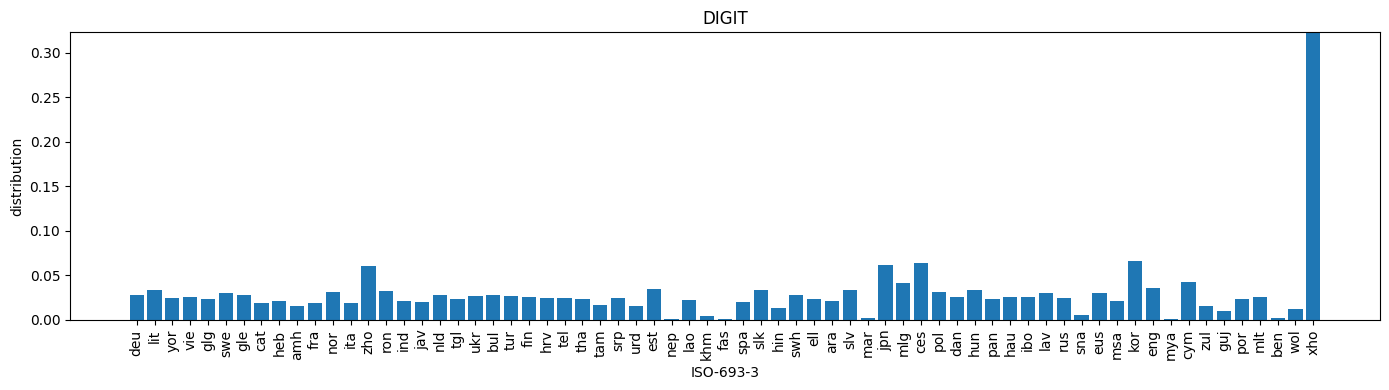

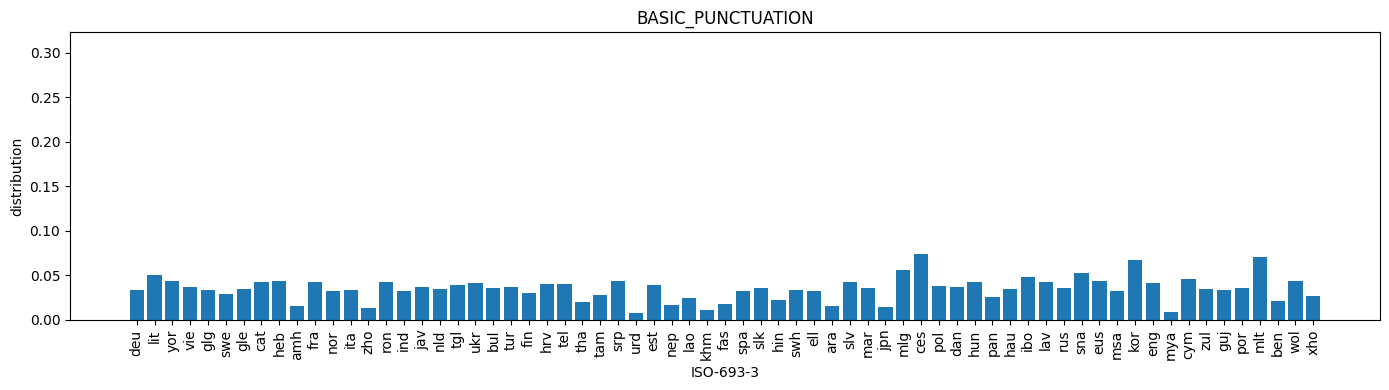

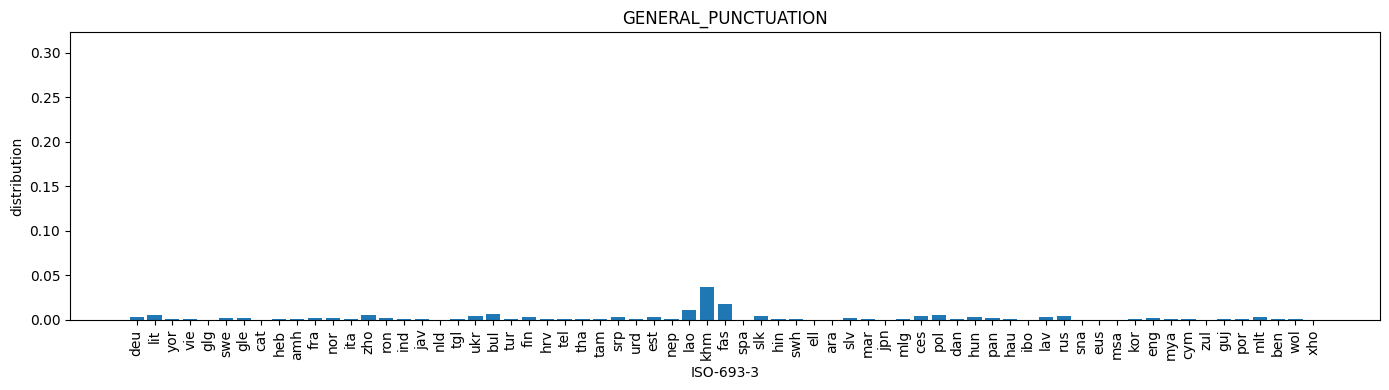

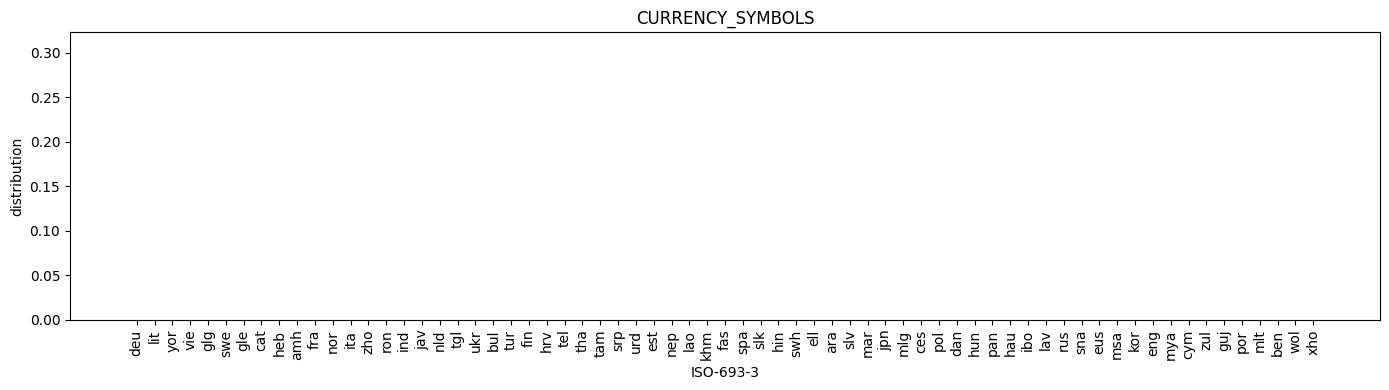

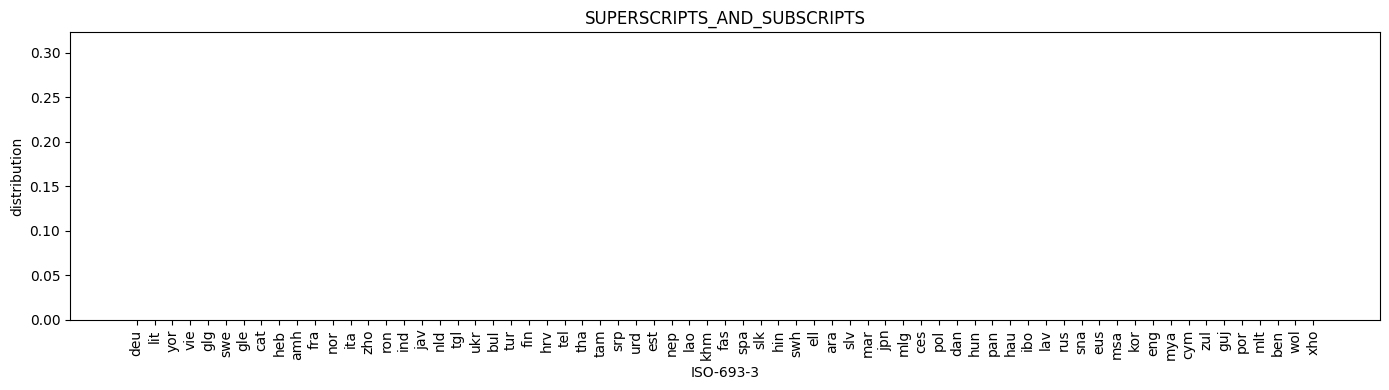

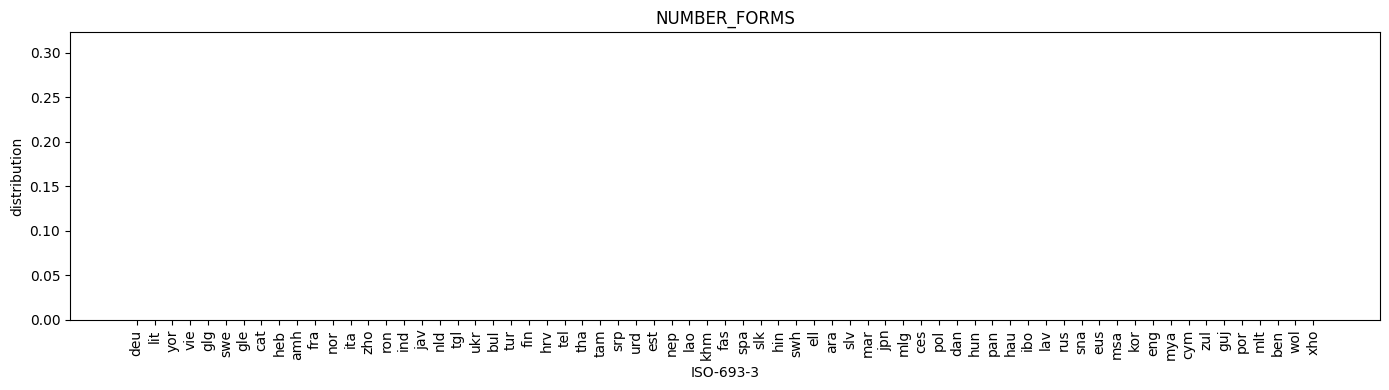

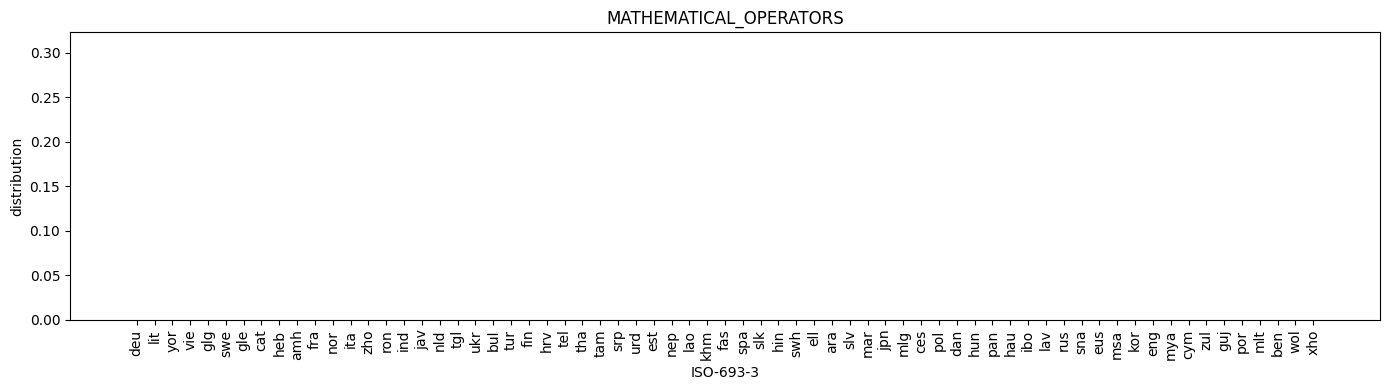

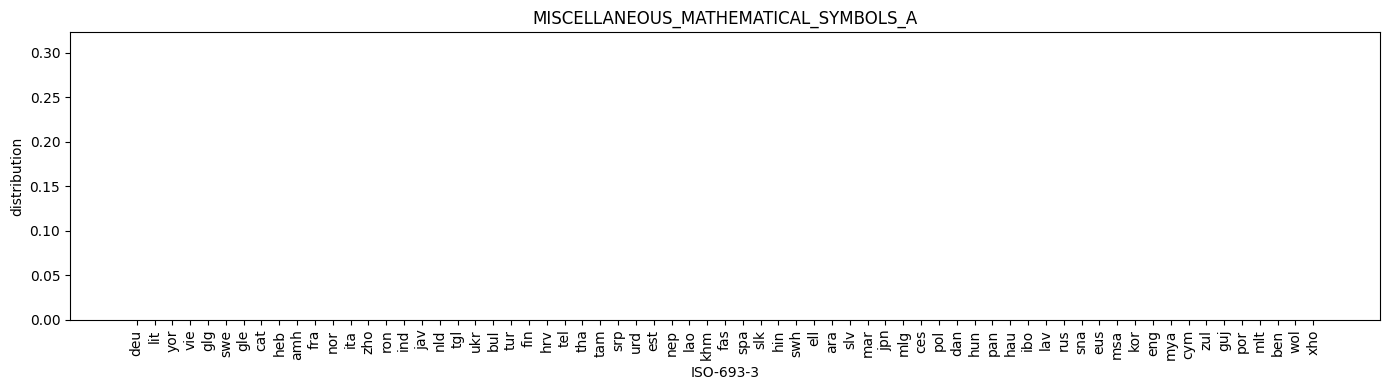

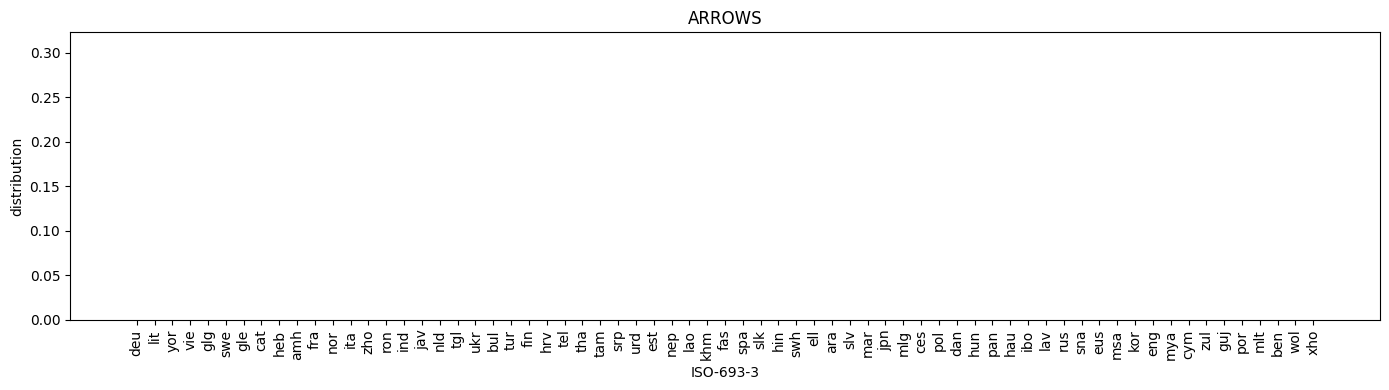

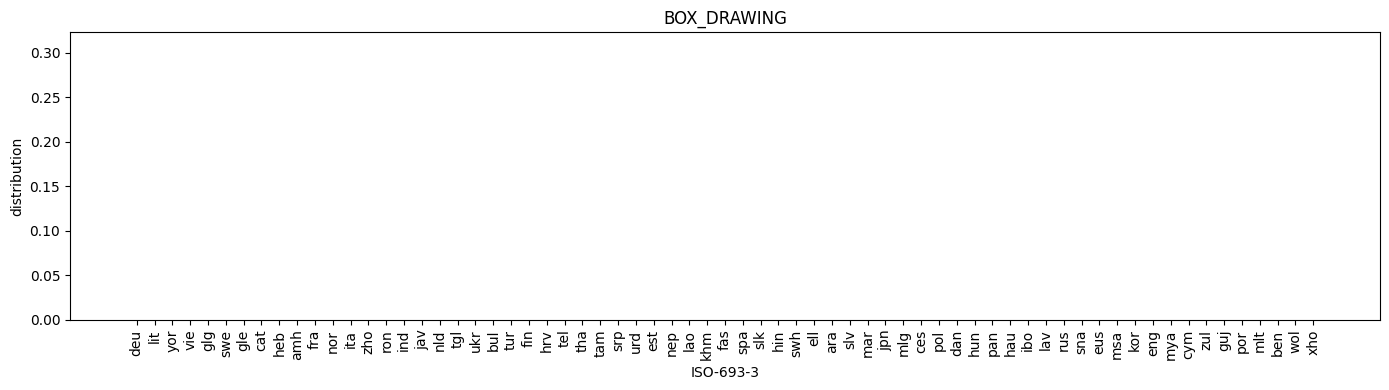

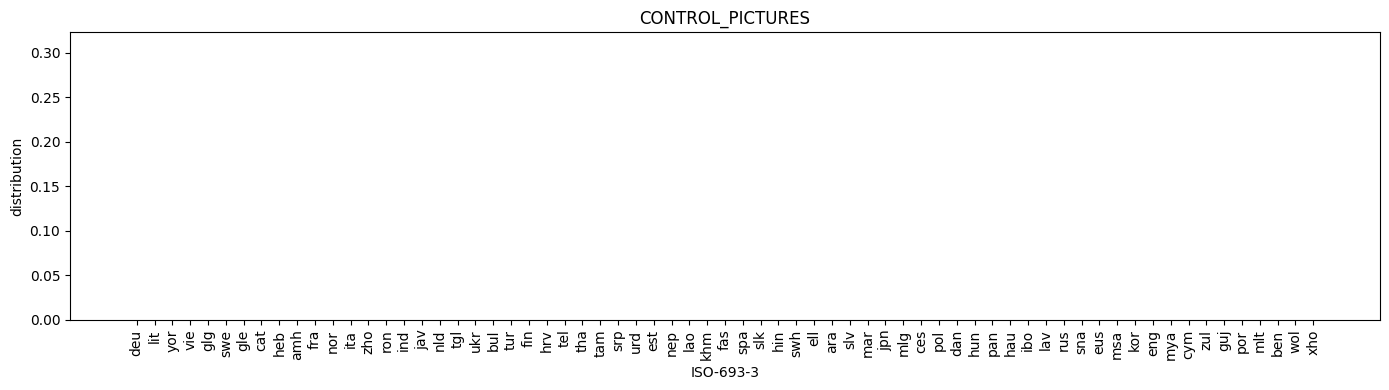

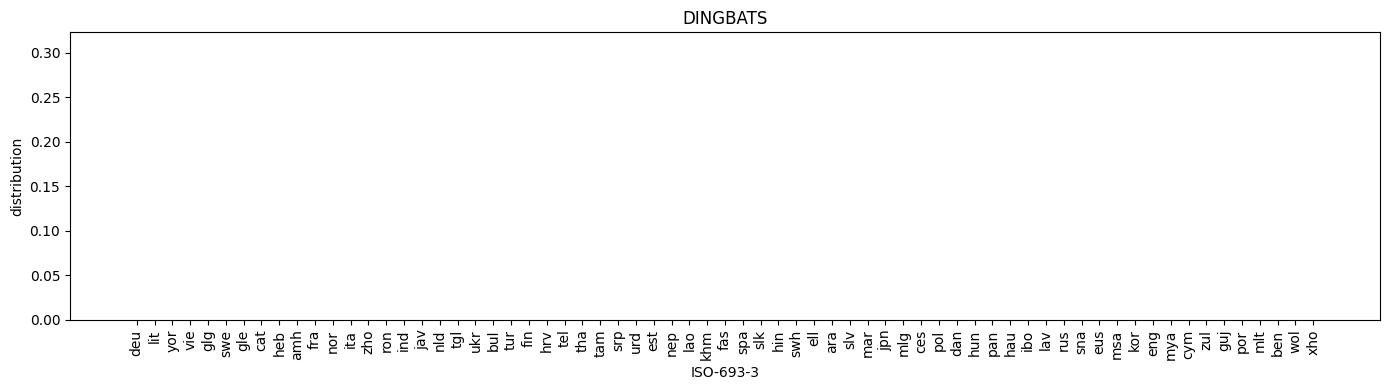

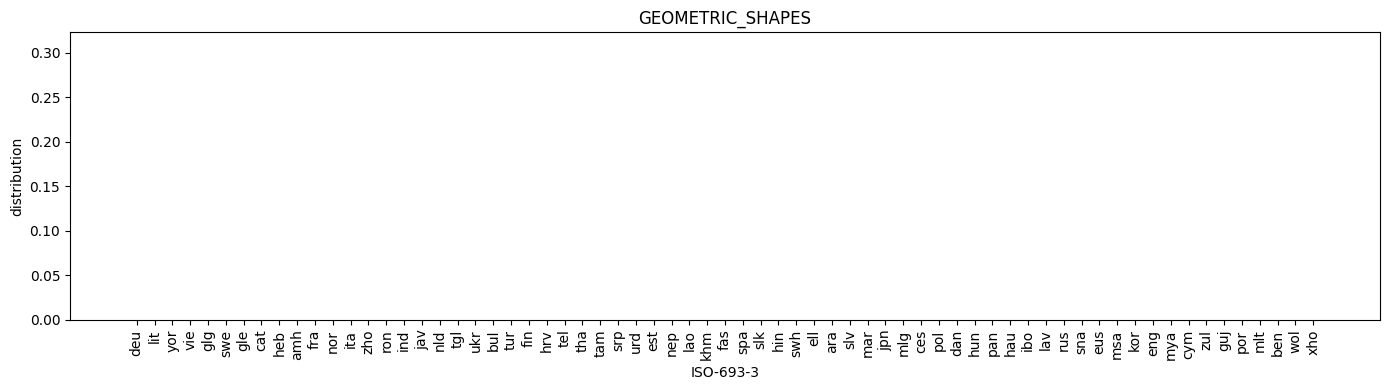

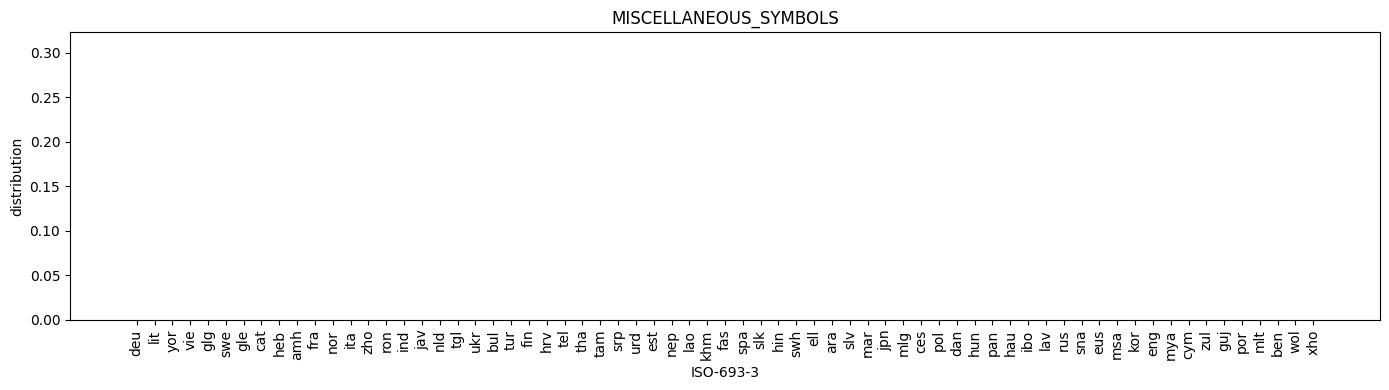

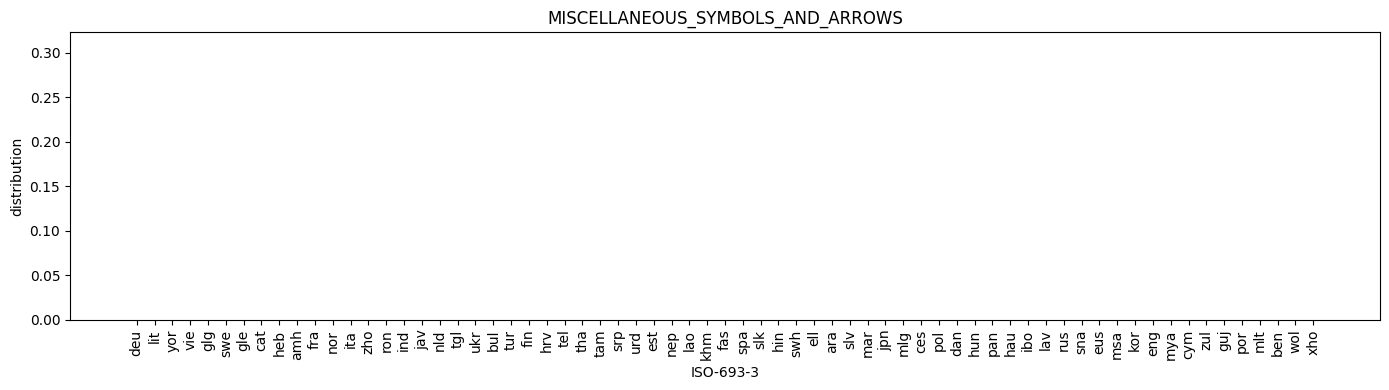

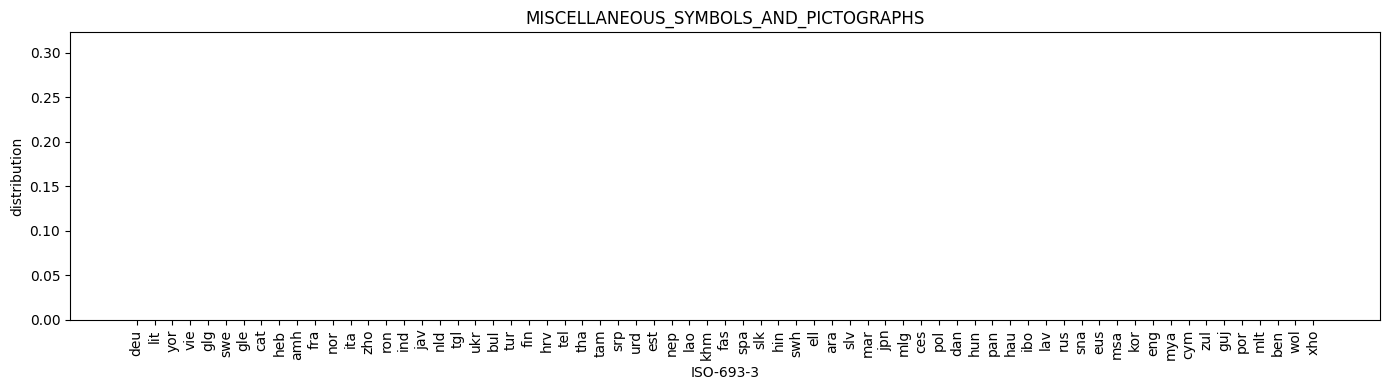

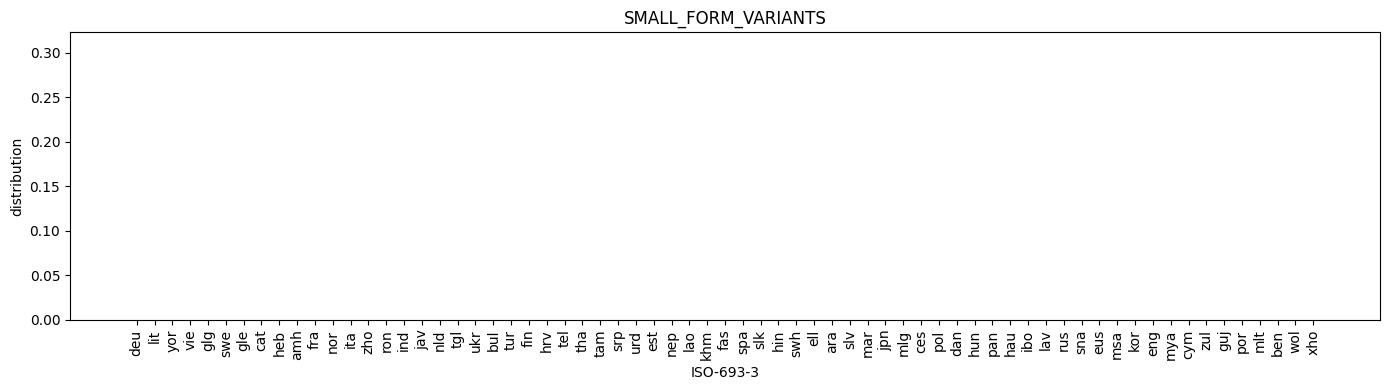

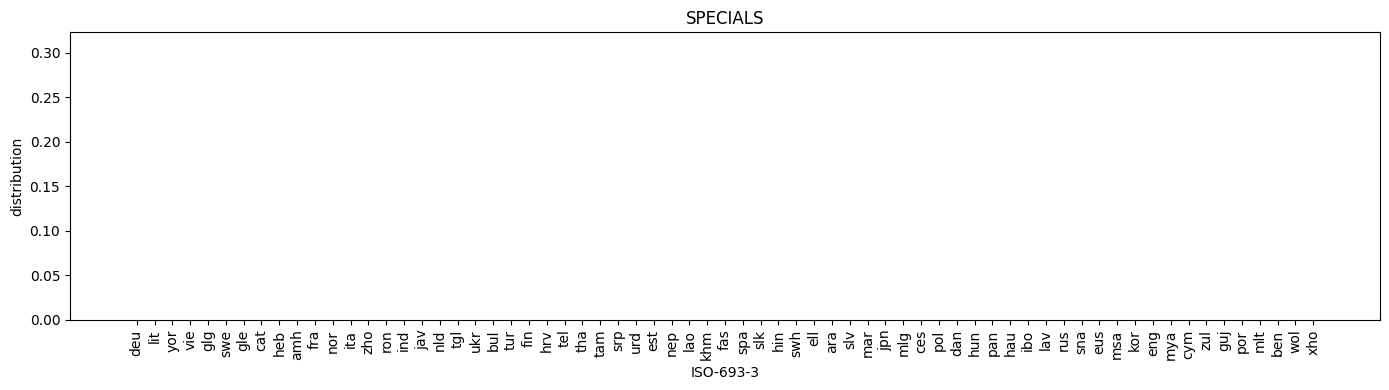

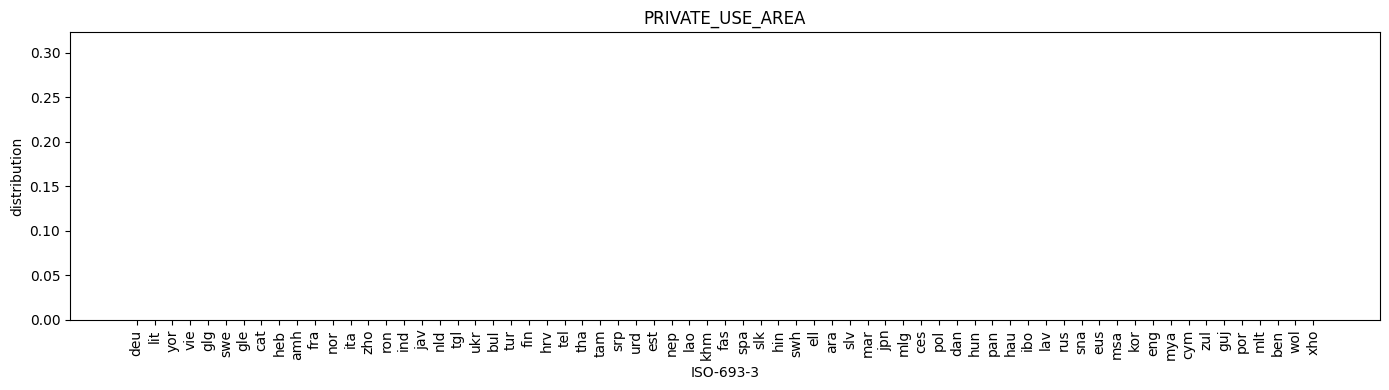

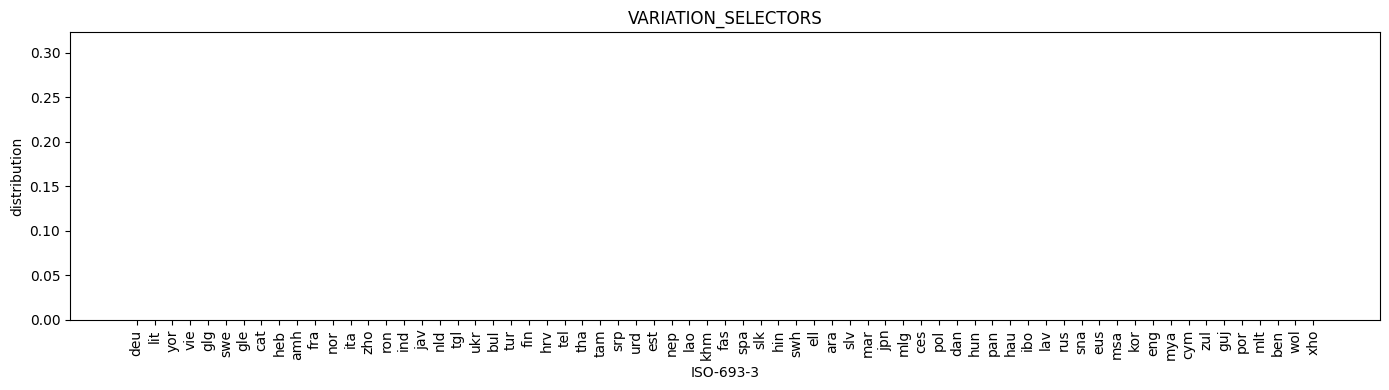

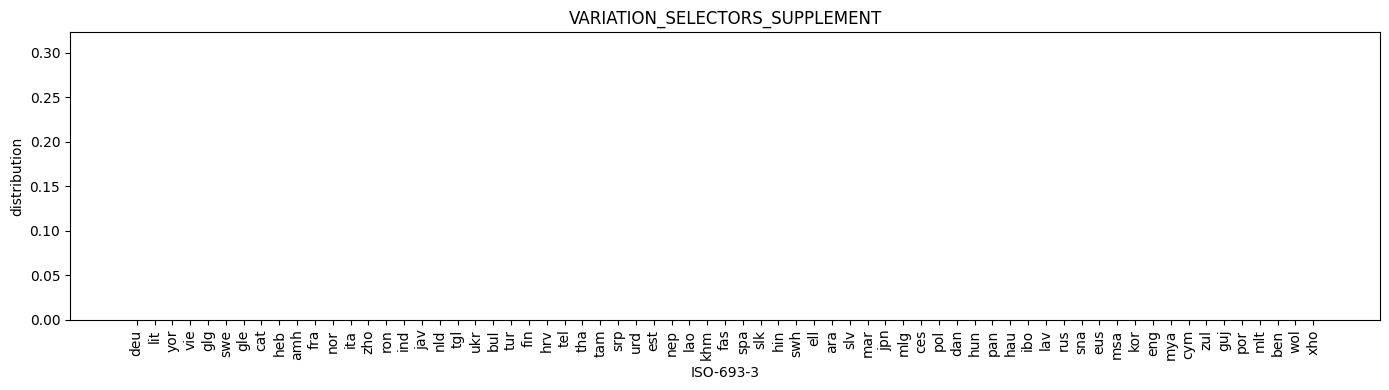

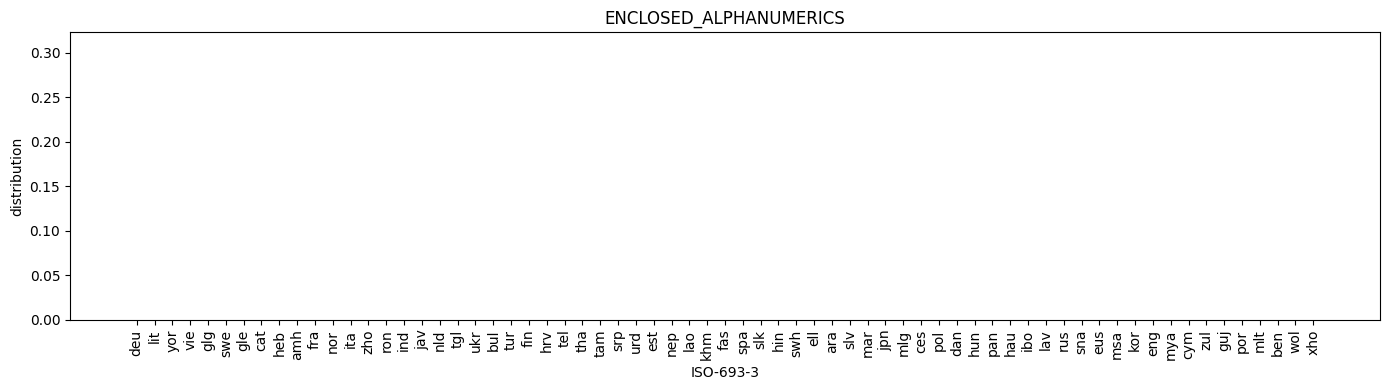

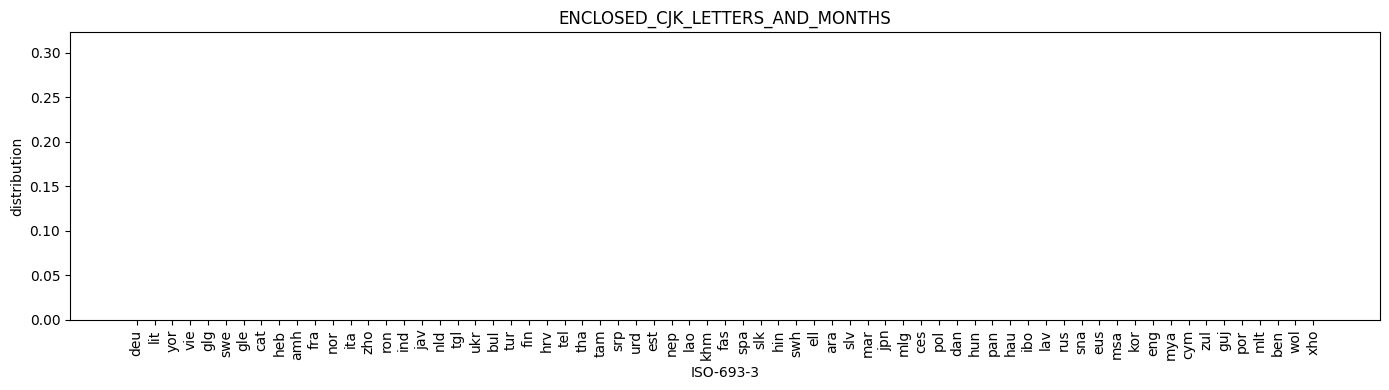

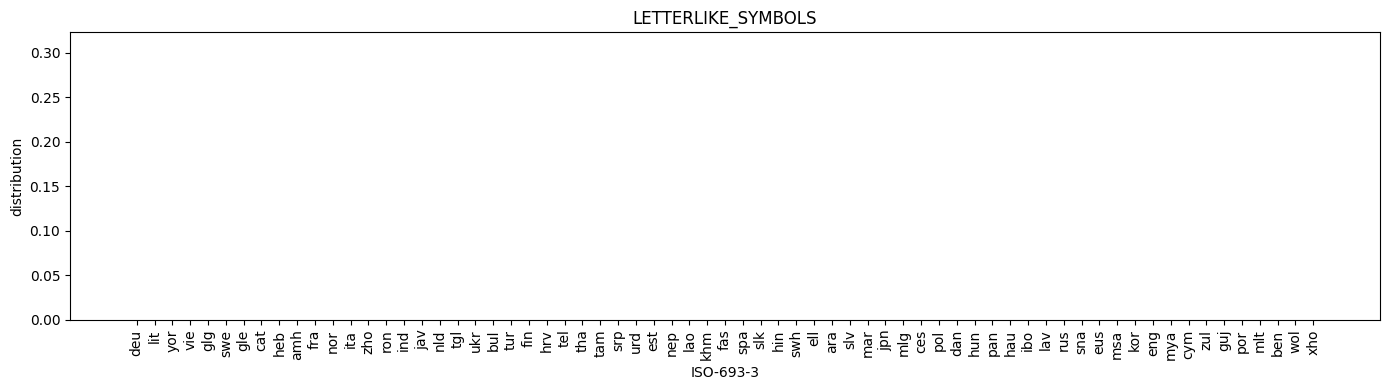

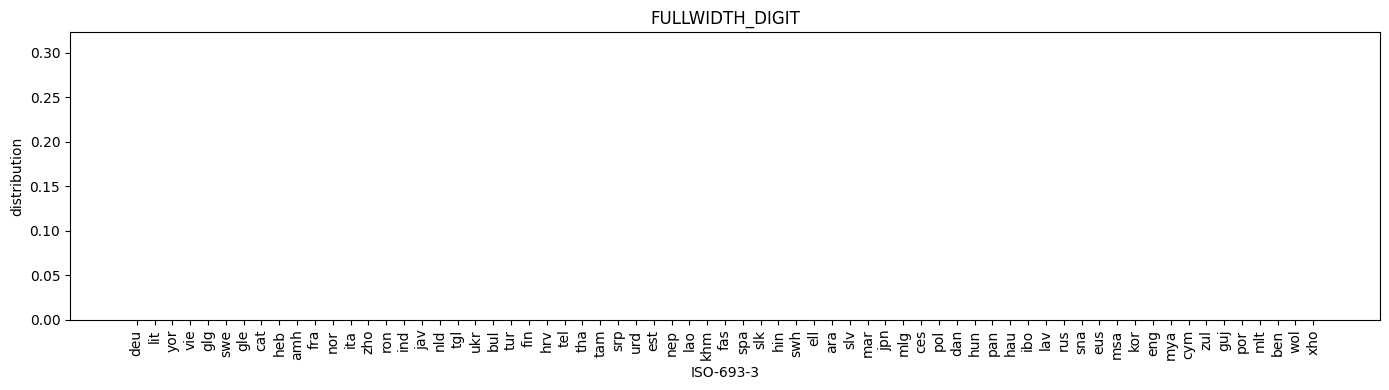

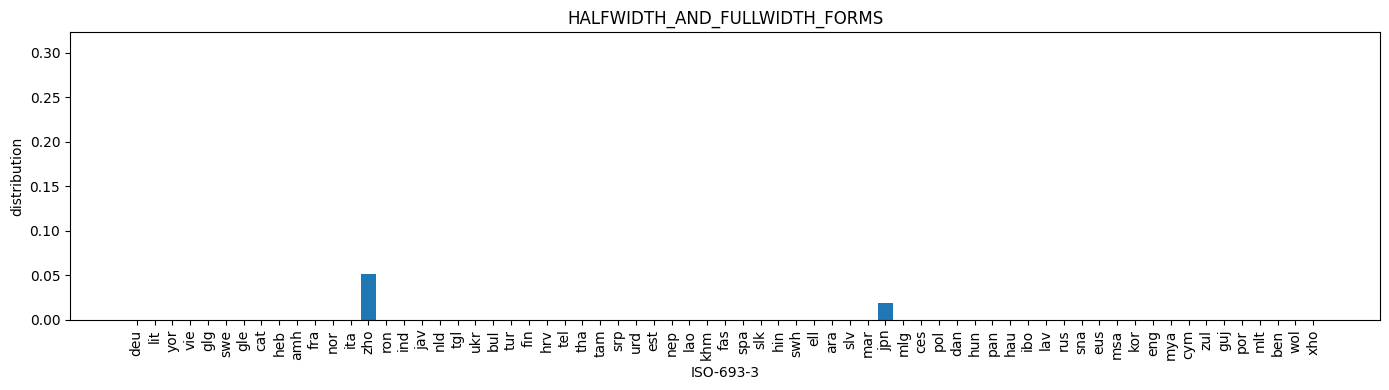

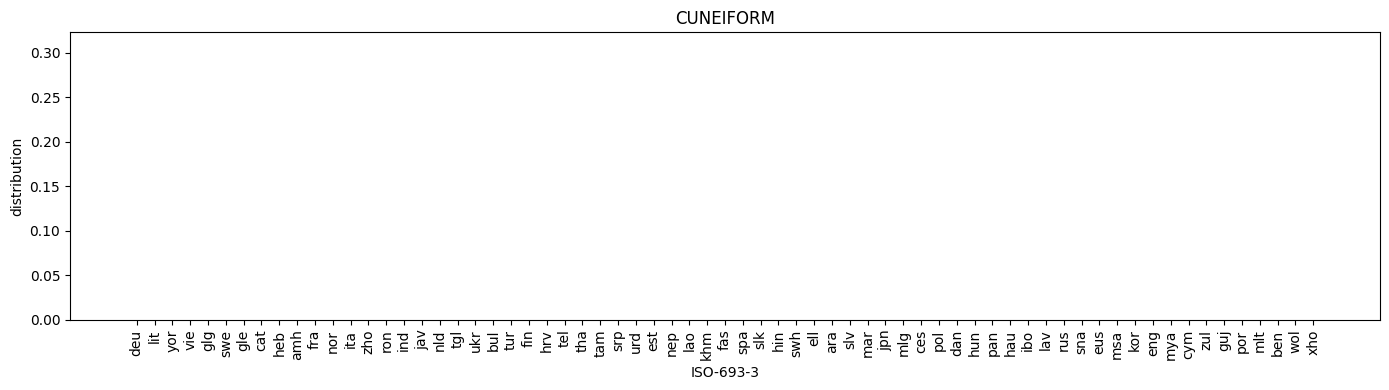

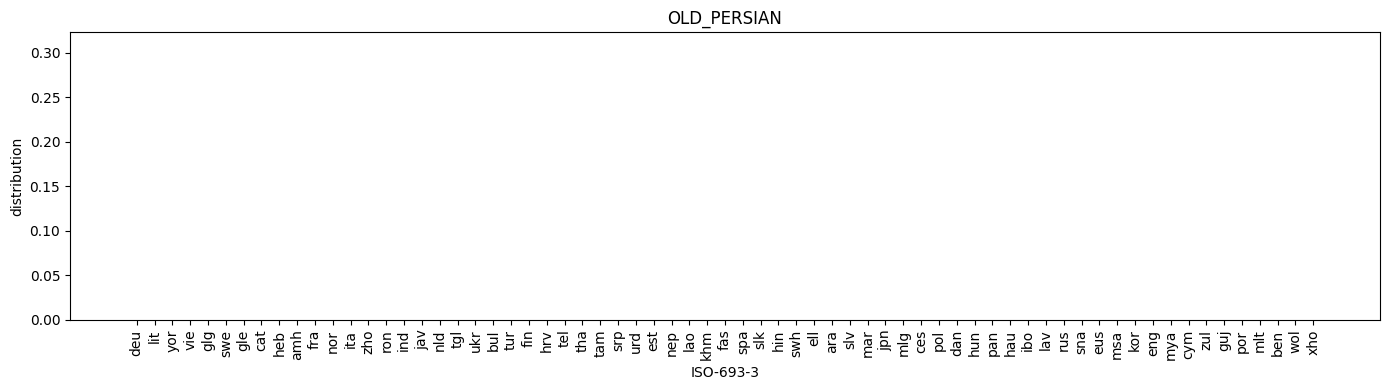

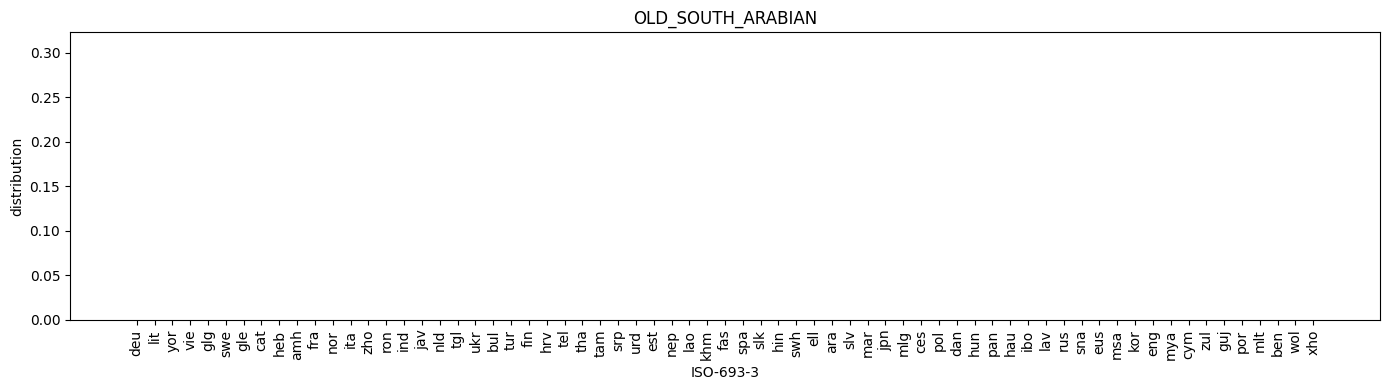

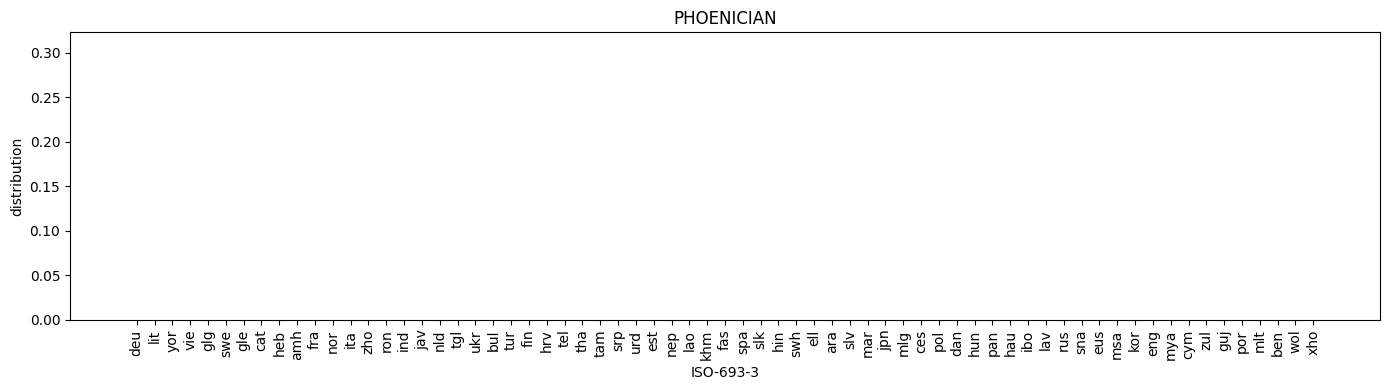

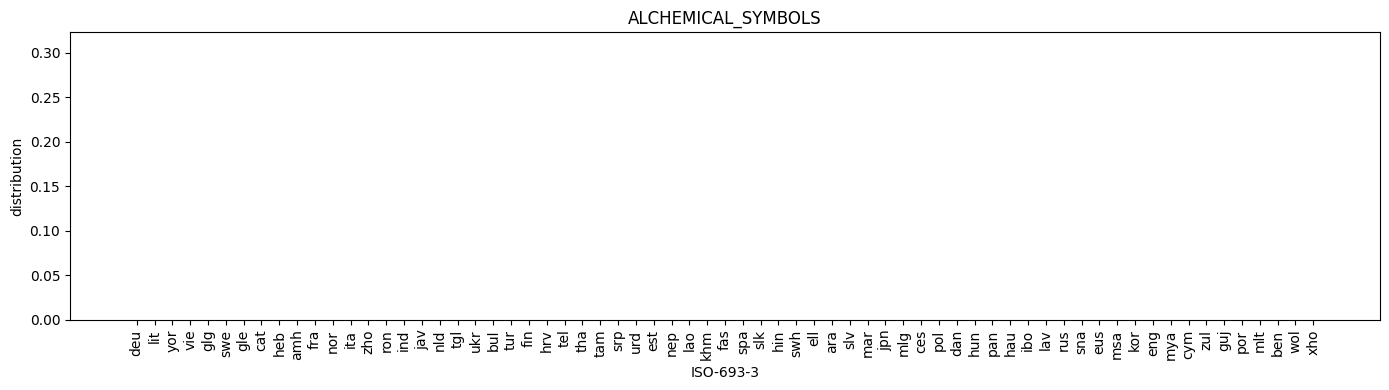

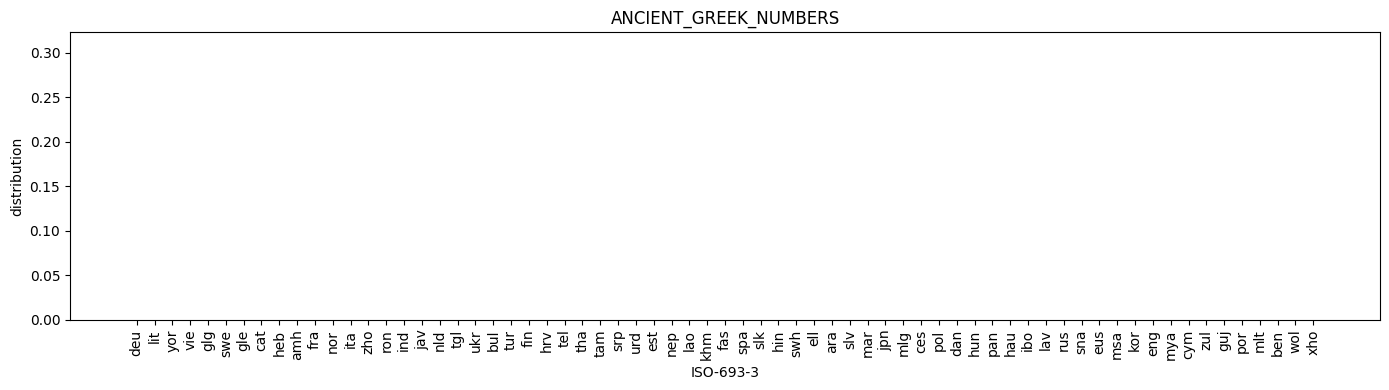

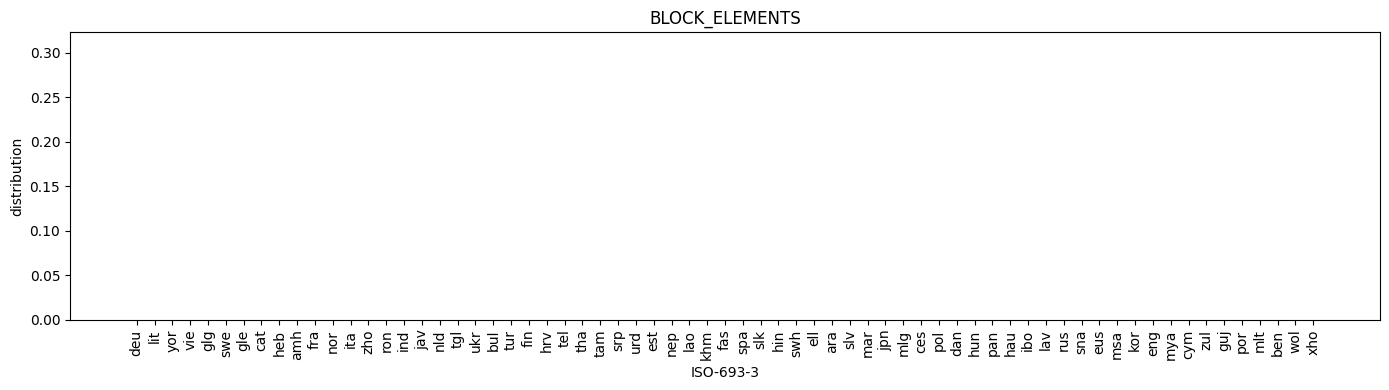

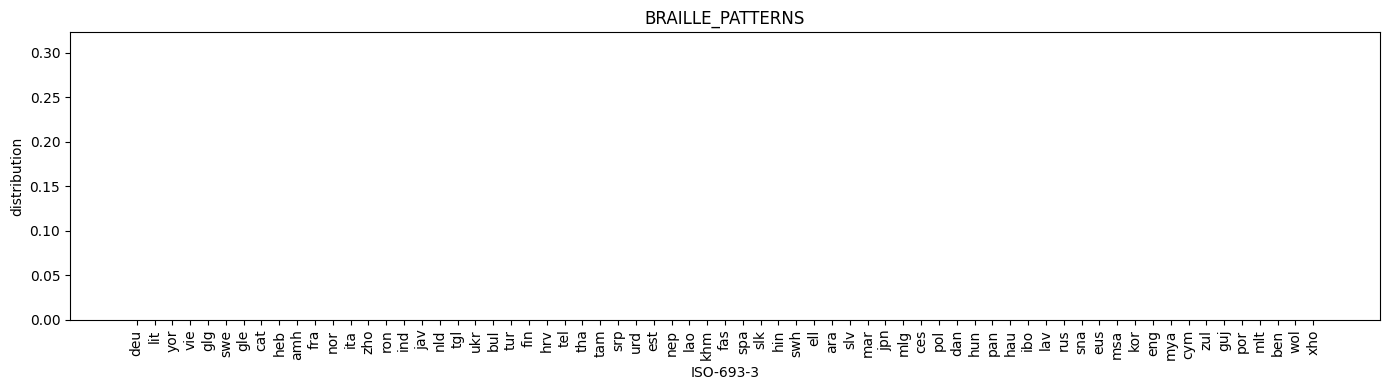

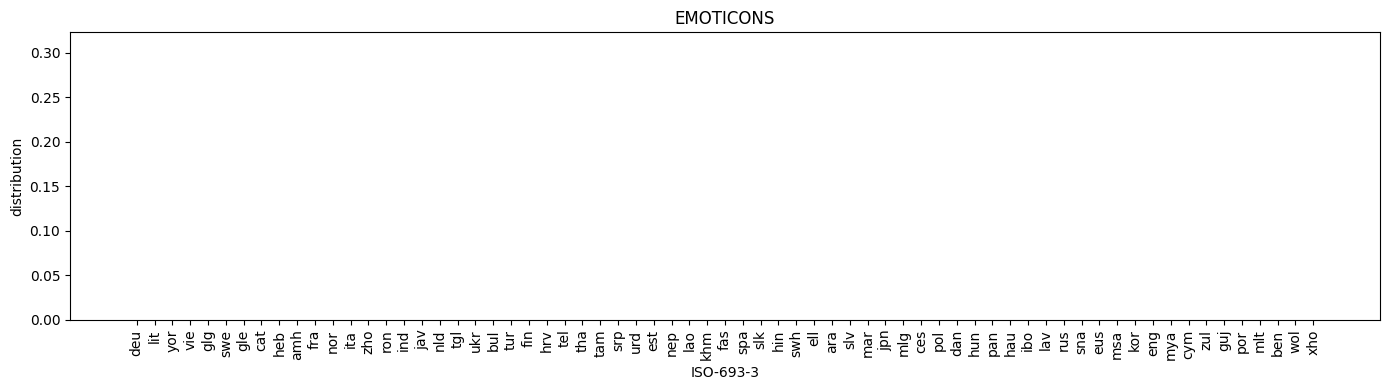

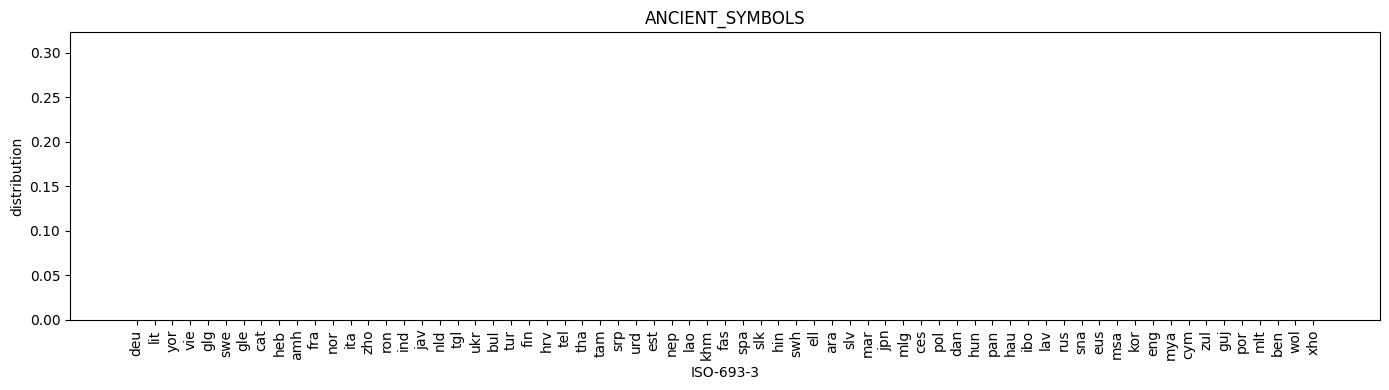

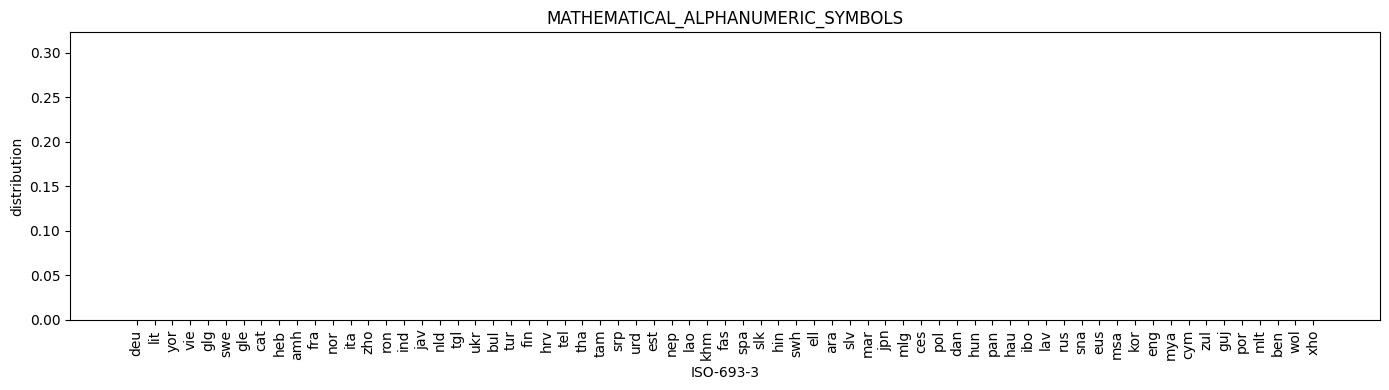

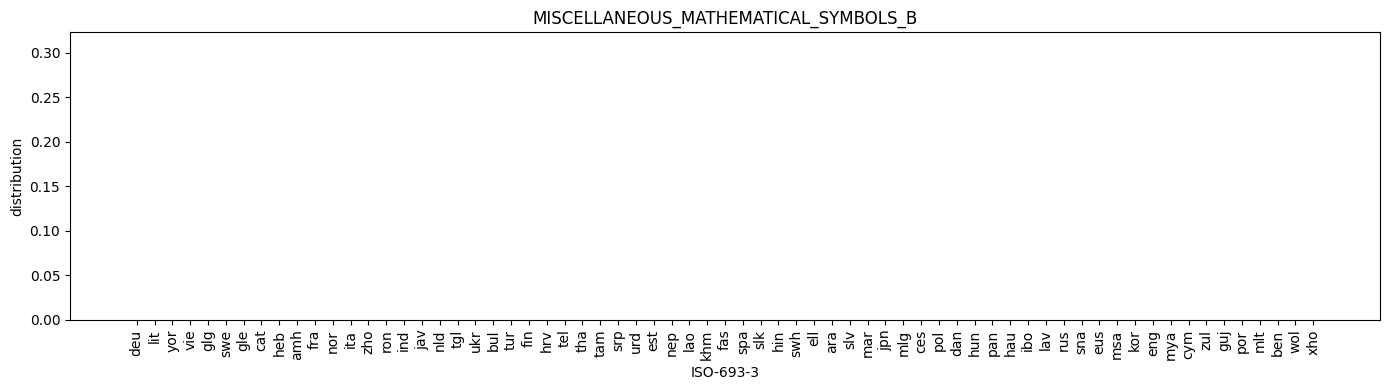

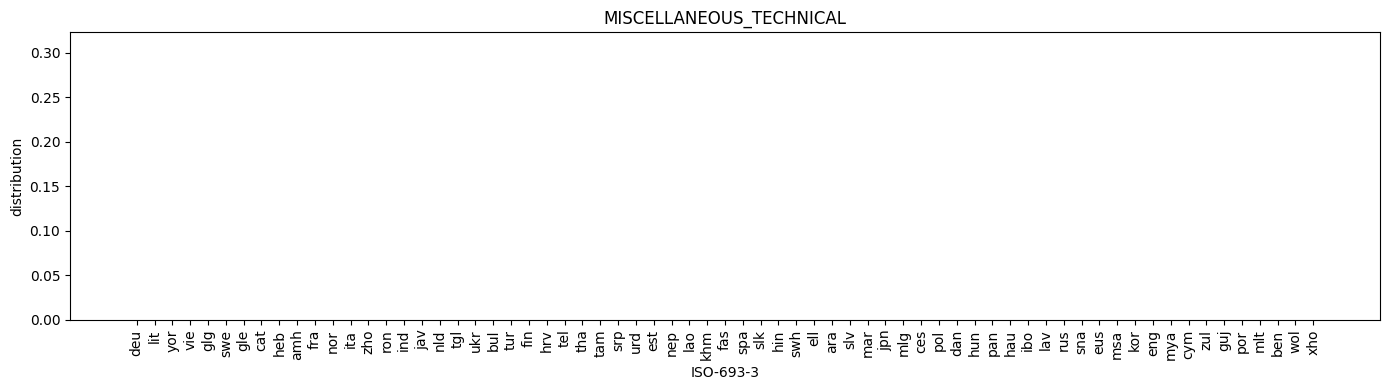

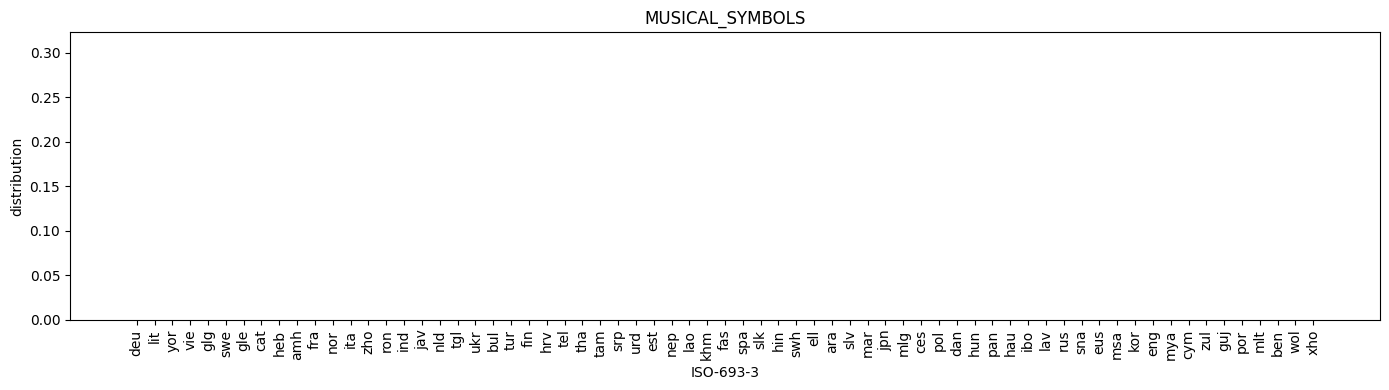

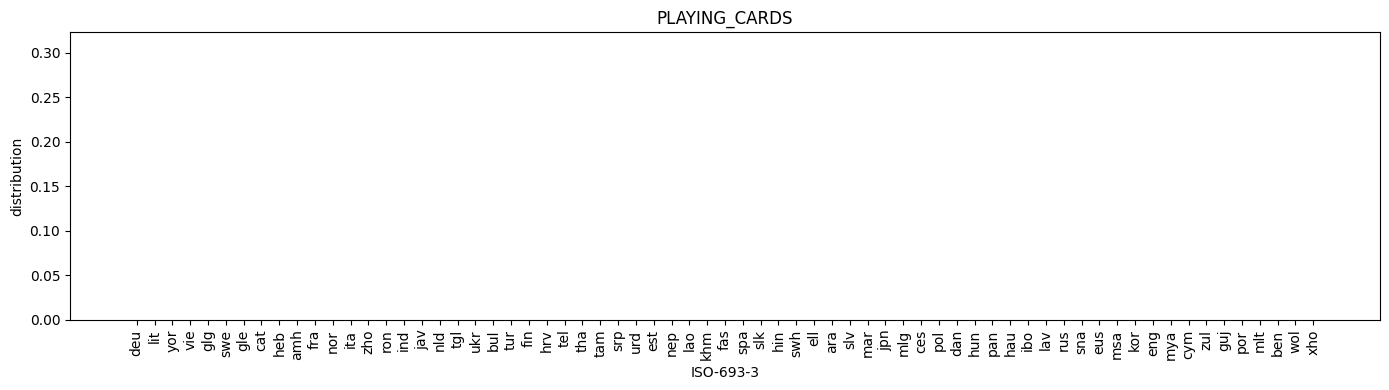

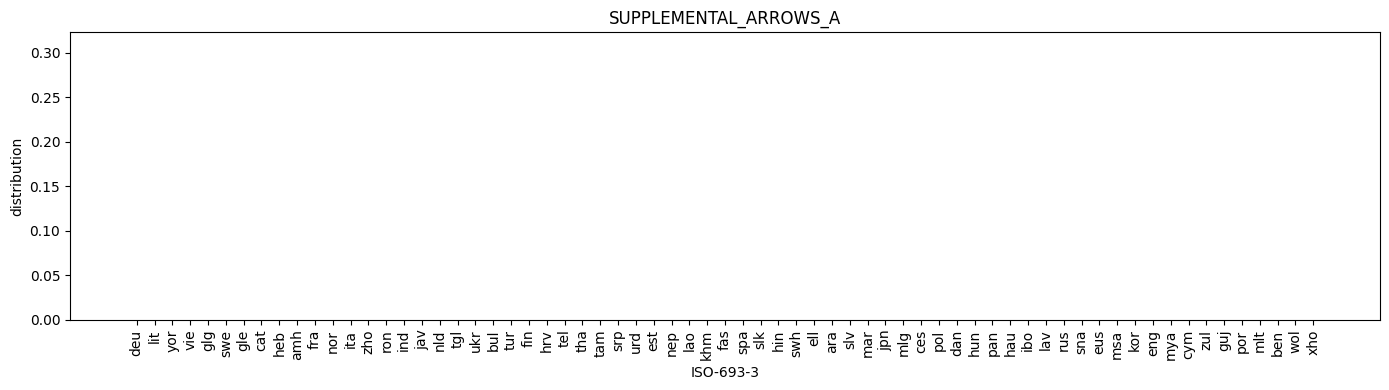

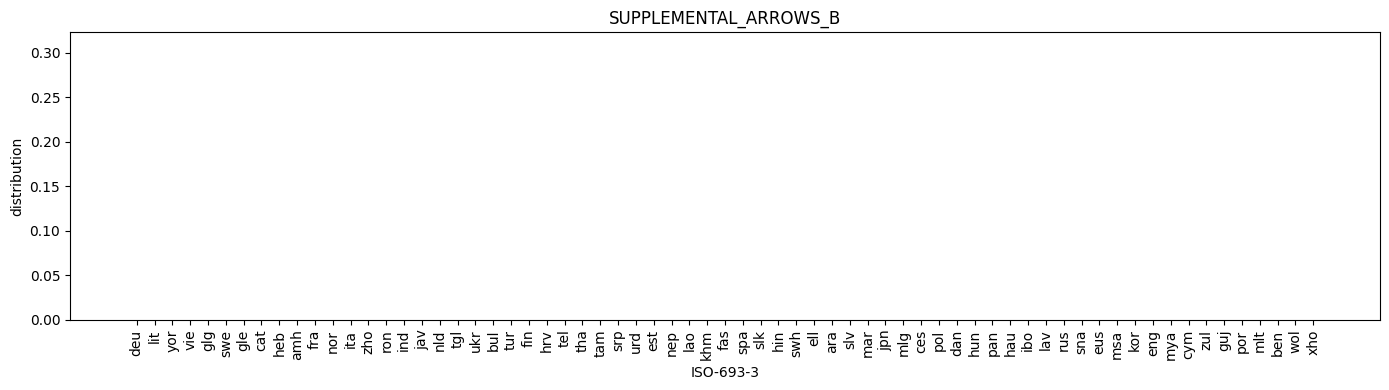

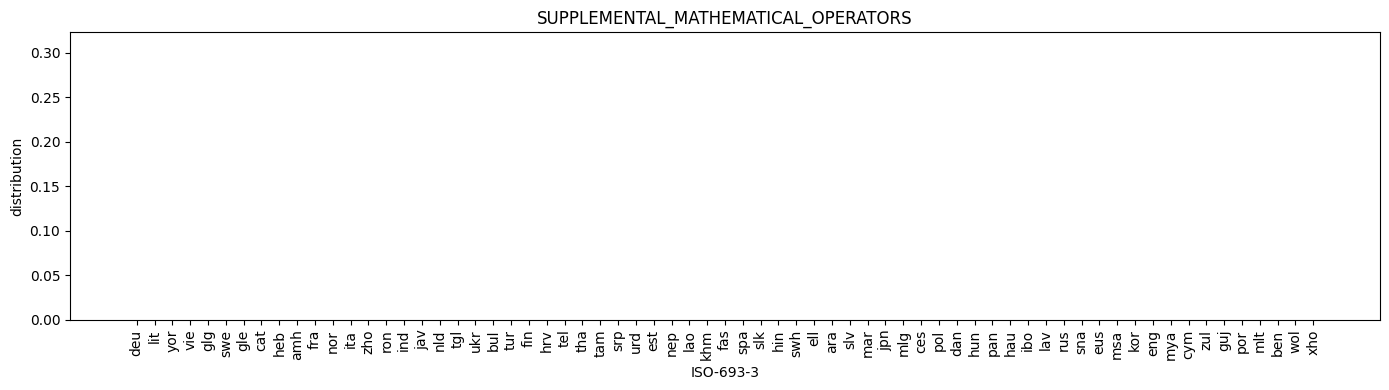

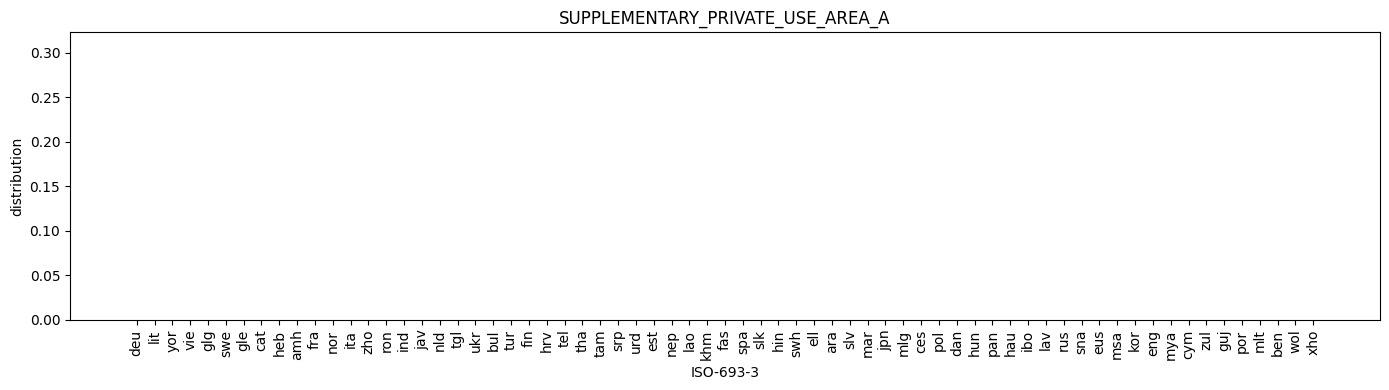

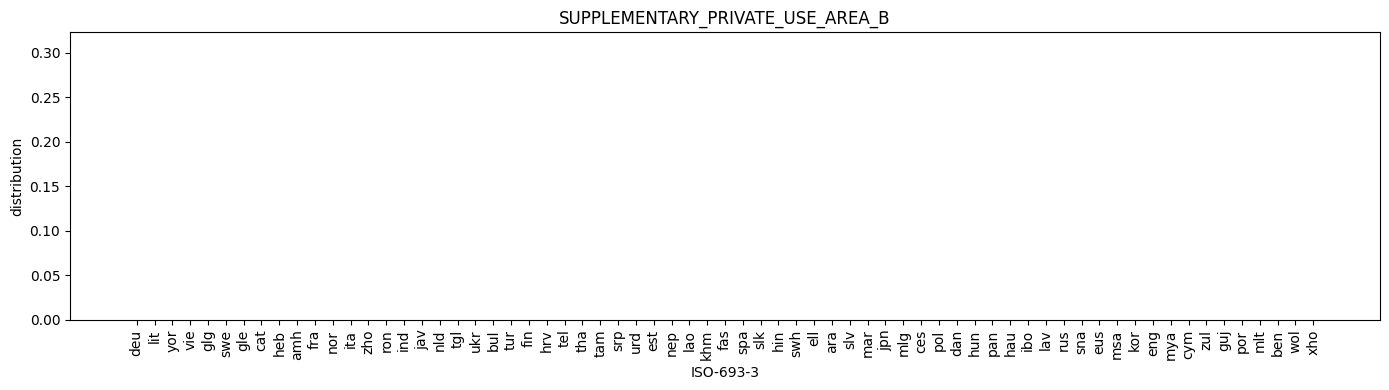

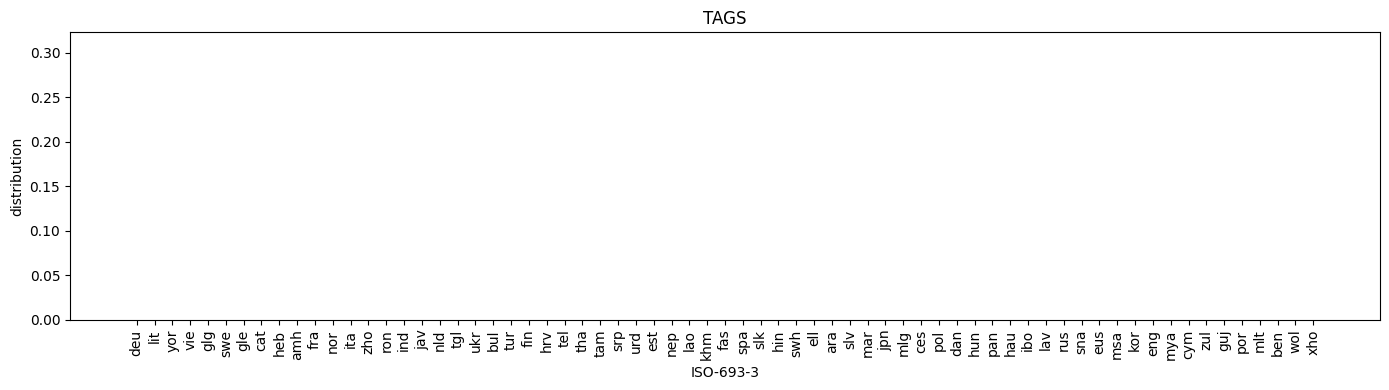

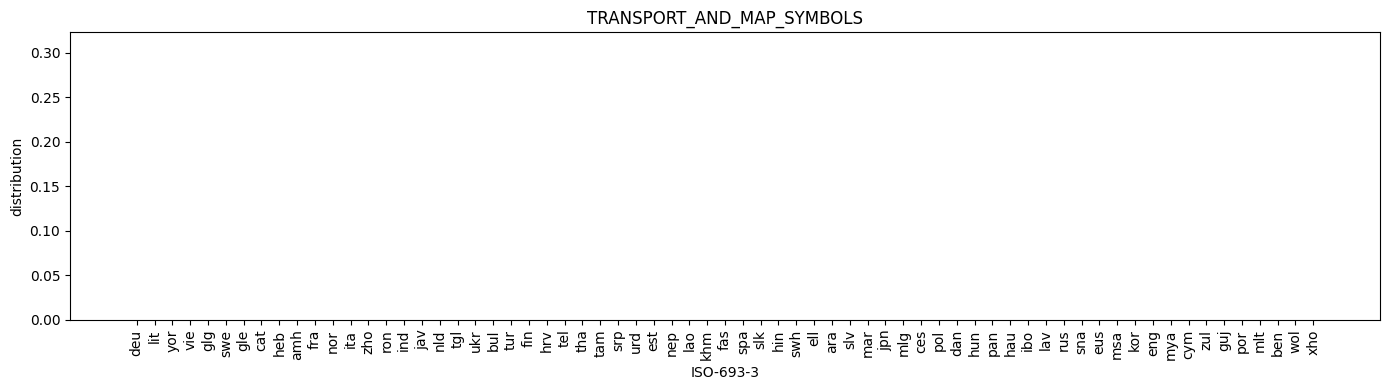

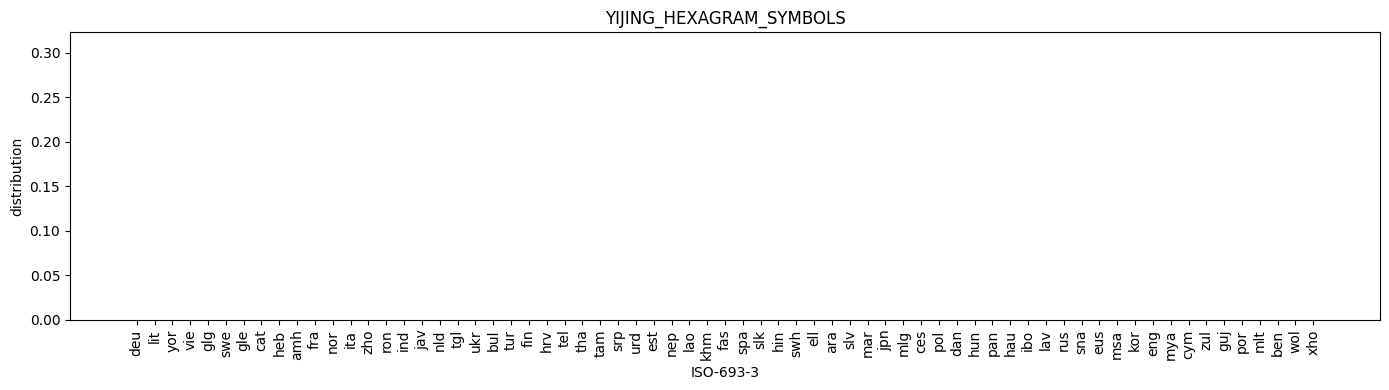

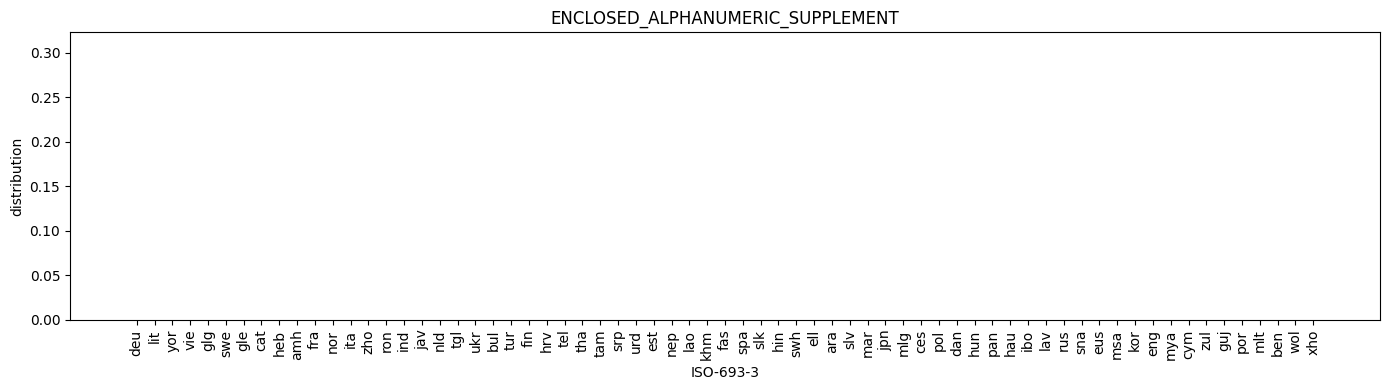

In [15]:
import matplotlib.pyplot as plt
y_max = df_rem.max().max()
for col in df_rem.columns:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(df_rem.index, df_rem[col])
    ax.set_ylim(0, y_max)
    ax.set_title(col)
    ax.set_xlabel('ISO-693-3')
    ax.set_ylabel('distribution')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

half width and full width block can be used to pre-classify chinese and japanese

In [16]:
for code in df_data['ISO-693-3'].unique():
    subset = df_data[df_data['ISO-693-3'] == code]['block_dist']
    count = subset.apply(lambda d: 1 if d and d.get('HALFWIDTH_AND_FULLWIDTH_FORMS', 0) > 0 else 0).sum()
    if count > 0:
        print(f"{code} : {count}")

deu : 2
lit : 5
yor : 2
vie : 186
glg : 10
swe : 7
gle : 2
cat : 35
heb : 5
amh : 16
fra : 46
nor : 5
ita : 6
zho : 19959
ron : 11
ind : 41
jav : 2
nld : 6
tgl : 31
ukr : 9
bul : 6
tur : 4
fin : 7
hrv : 5
tel : 1
tha : 178
tam : 14
srp : 6
urd : 4
est : 2
lao : 27
khm : 55
fas : 8
spa : 27
slk : 1
hin : 6
swh : 5
ell : 8
ara : 7
slv : 2
jpn : 19759
mlg : 2
ces : 4
pol : 13
dan : 1
hun : 3
pan : 4
hau : 9
ibo : 5
lav : 2
rus : 19
sna : 1
eus : 9
msa : 46
kor : 563
eng : 20
mya : 21
cym : 5
guj : 4
por : 5
mlt : 5
ben : 8


In [17]:
cjk_blocks = ['CJK_UNIFIED_IDEOGRAPHS', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_A', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_B', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_C', 'CJK_UNIFIED_IDEOGRAPHS_EXTENSION_D']
jpn_signal = lambda d: d.get('HIRAGANA',0) + d.get('KATAKANA',0) + d.get('HALFWIDTH_AND_FULLWIDTH_FORMS',0) > 0
zho_signal = lambda d: any(d.get(b,0) > 0 for b in cjk_blocks)
print("jpn caught  :", df_data[df_data['ISO-693-3']=='jpn']['block_dist'].apply(jpn_signal).sum())
print("zho caught  :", df_data[df_data['ISO-693-3']=='zho']['block_dist'].apply(zho_signal).sum())
print("unnecessary :", df_data[~df_data['ISO-693-3'].isin(['jpn','zho'])]['block_dist'].apply(lambda d: jpn_signal(d) or zho_signal(d)).sum())

jpn caught  : 19998
zho caught  : 20000
unnecessary : 27821


In [18]:
jpn_signal = lambda d: d.get('HIRAGANA',0) + d.get('KATAKANA',0) > 0
kor_signal = lambda d: d.get('HANGUL_SYLLABLES',0) + d.get('HANGUL_JAMO',0) + d.get('HANGUL_COMPATIBILITY_JAMO',0) > 0
zho_signal = lambda d: not jpn_signal(d) and not kor_signal(d) and any(d.get(b,0) > 0 for b in cjk_blocks)
def classify_cjk_v2(d):
    if not d:
        return None
    has_hira_kata = d.get('HIRAGANA',0) + d.get('KATAKANA',0) > 0
    has_fullwidth = d.get('HALFWIDTH_AND_FULLWIDTH_FORMS',0) > 0
    has_cjk = any(d.get(b,0) > 0 for b in cjk_blocks)
    if has_hira_kata:
        return 'jpn'
    if has_fullwidth and not has_cjk:
        return 'jpn'
    if has_cjk:
        return 'zho'
    return None
df_commonLID['cjk_flag'] = df_commonLID['block_dist'].apply(classify_cjk_v2)
jpn_rows = df_commonLID[df_commonLID['tag'] == 'jpn']
zho_rows = df_commonLID[df_commonLID['tag'] == 'zho']
rest_rows = df_commonLID[~df_commonLID['tag'].isin(['jpn','zho'])]
jpn_correct = (jpn_rows['cjk_flag'] == 'jpn').sum()
jpn_incorrect = len(jpn_rows) - jpn_correct
zho_correct = (zho_rows['cjk_flag'] == 'zho').sum()
zho_incorrect = len(zho_rows) - zho_correct
rest_correct = rest_rows['cjk_flag'].isna().sum()
rest_incorrect = len(rest_rows) - rest_correct
print(f"jpn  : acc {jpn_correct/len(jpn_rows):.2f} | correct {jpn_correct} | incorrect {jpn_incorrect}")
print(f"zho  : acc {zho_correct/len(zho_rows):.2f} | correct {zho_correct} | incorrect {zho_incorrect}")
print(f"rest : acc {rest_correct/len(rest_rows):.2f} | correct {rest_correct} | incorrect {rest_incorrect}")

jpn  : acc 0.96 | correct 3207 | incorrect 137
zho  : acc 0.99 | correct 11571 | incorrect 167
rest : acc 0.99 | correct 355871 | incorrect 2277


In [19]:
df_data['cjk_flag'] = df_data['block_dist'].apply(classify_cjk_v2)
jpn_rows = df_data[df_data['ISO-693-3'] == 'jpn']
zho_rows = df_data[df_data['ISO-693-3'] == 'zho']
rest_rows = df_data[~df_data['ISO-693-3'].isin(['jpn','zho'])]
jpn_correct = (jpn_rows['cjk_flag'] == 'jpn').sum()
jpn_incorrect = len(jpn_rows) - jpn_correct
zho_correct = (zho_rows['cjk_flag'] == 'zho').sum()
zho_incorrect = len(zho_rows) - zho_correct
rest_correct = rest_rows['cjk_flag'].isna().sum()
rest_incorrect = len(rest_rows) - rest_correct
print(f"jpn  : acc {jpn_correct/len(jpn_rows):.2f} | correct {jpn_correct} | incorrect {jpn_incorrect}")
print(f"zho  : acc {zho_correct/len(zho_rows):.2f} | correct {zho_correct} | incorrect {zho_incorrect}")
print(f"rest : acc {rest_correct/len(rest_rows):.2f} | correct {rest_correct} | incorrect {rest_incorrect}")

jpn  : acc 1.00 | correct 19997 | incorrect 3
zho  : acc 0.96 | correct 19287 | incorrect 713
rest : acc 0.98 | correct 1181014 | incorrect 27821


### **Rest**

In [20]:
for code in df_data['ISO-693-3'].unique():
    exec(f"""
lang_val = df_{code}['lang'].iloc[0]
comm_vals = df_{code}['COMM'].value_counts().index.tolist()
thresh_val = f"{{df_{code}['THRESH'].min():.2f}}" if len(comm_vals) < 2 else "NA"
if len(comm_vals) > 3:
    comm_str = "['" + "', '".join(comm_vals[:3]) + "', ..."
else:
    comm_str = str(comm_vals)
print(f"df_{code} : {{lang_val}} : {{comm_str}} : {{thresh_val}}")
""")

df_deu : german : ['BASIC_LATIN'] : 0.56
df_lit : lithuanian : ['BASIC_LATIN', 'CYRILLIC', 'BASIC_PUNCTUATION'] : NA
df_yor : yoruba : ['BASIC_LATIN', 'HEBREW', 'LATIN_EXTENDED_LETTER', ... : NA
df_vie : vietnamese : ['BASIC_LATIN', 'DIGIT', 'CJK_UNIFIED_IDEOGRAPHS'] : NA
df_glg : galician : ['BASIC_LATIN', 'DIGIT', 'CJK_UNIFIED_IDEOGRAPHS'] : NA
df_swe : swedish : ['BASIC_LATIN', 'DIGIT'] : NA
df_gle : irish : ['BASIC_LATIN', 'DIGIT'] : NA
df_cat : catalan : ['BASIC_LATIN', 'BASIC_PUNCTUATION', 'DIGIT', ... : NA
df_heb : hebrew : ['HEBREW', 'BASIC_LATIN', 'DIGIT'] : NA
df_amh : amharic : ['ETHIOPIC', 'BASIC_LATIN', 'DIGIT', ... : NA
df_fra : french : ['BASIC_LATIN', 'BASIC_PUNCTUATION'] : NA
df_nor : norwegian : ['BASIC_LATIN', 'DIGIT'] : NA
df_ita : italian : ['BASIC_LATIN', 'DIGIT', 'CYRILLIC'] : NA
df_zho : chinese : ['CJK_UNIFIED_IDEOGRAPHS', 'BASIC_LATIN', 'DIGIT', ... : NA
df_ron : romanian : ['BASIC_LATIN', 'ARABIC'] : NA
df_ind : indonesian : ['BASIC_LATIN', 'DIGIT'] : NA
df_j

In [21]:
afr_langs = ['amh', 'hau', 'ibo', 'mlg', 'sna', 'swh', 'wol', 'xho', 'yor', 'zul']
sea_langs = ['tgl', 'msa', 'ind', 'vie', 'jav', 'khm', 'tha', 'lao', 'zho', 'mya', 'jpn', 'kor']
ind_langs = ['hin', 'mar', 'ben', 'guj', 'pan', 'tam', 'tel', 'nep']
mea_langs = ['ara', 'fas', 'urd', 'tur', 'mlt', 'heb']
eng_langs = ['eng']
eur_langs = ['nld', 'fra', 'ita', 'por', 'ron', 'spa', 'ces', 'pol', 'ukr', 'rus',
             'ell', 'deu', 'dan', 'swe', 'nor', 'cat', 'glg', 'cym', 'gle', 'eus',
             'hrv', 'lav', 'lit', 'slk', 'slv', 'est', 'fin', 'hun', 'srp', 'bul']

In [22]:
unique_script  = ['amh','mya','tam','tel','ben','guj','pan','khm','heb','jpn','kor','zho','tha','lao']
devanagari     = ['hin','mar','nep']
arabic_script  = ['ara','fas','urd']
cyrillic       = ['rus','ukr','bul','srp']
greek          = ['ell']
latin          = ['wol','swh','swe','fin','slk','dan','hun','ces','xho','gle','tur','lav','eng','glg','ita','por','pol','hau','nld','ron','spa','tgl','slv','cat','fra','cym','mlg','ind','vie','eus','yor','est','jav','sna','lit','ibo','mlt','zul','nor','msa','deu','hrv']
import re
script_patterns = {
    'amh': re.compile(r'[\u1200-\u137F]'),
    'mya': re.compile(r'[\u1000-\u109F]'),
    'tam': re.compile(r'[\u0B80-\u0BFF]'),
    'tel': re.compile(r'[\u0C00-\u0C7F]'),
    'ben': re.compile(r'[\u0980-\u09FF]'),
    'guj': re.compile(r'[\u0A80-\u0AFF]'),
    'pan': re.compile(r'[\u0A00-\u0A7F]'),
    'khm': re.compile(r'[\u1780-\u17FF]'),
    'heb': re.compile(r'[\u0590-\u05FF]'),
    'jpn': re.compile(r'[\u3040-\u309F\u30A0-\u30FF]'),
    'kor': re.compile(r'[\uAC00-\uD7AF\u1100-\u11FF]'),
    'zho': re.compile(r'[\u4E00-\u9FFF\u3400-\u4DBF]'),
    'tha': re.compile(r'[\u0E00-\u0E7F]'),
    'lao': re.compile(r'[\u0E80-\u0EFF]'),
    'hin': re.compile(r'[\u0900-\u097F]'),
    'mar': re.compile(r'[\u0900-\u097F]'),
    'nep': re.compile(r'[\u0900-\u097F]'),
    'ara': re.compile(r'[\u0600-\u06FF]'),
    'fas': re.compile(r'[\u0600-\u06FF]'),
    'urd': re.compile(r'[\u0600-\u06FF]'),
    'wol': re.compile(r'[\u0600-\u06FF]'),
    'rus': re.compile(r'[\u0400-\u04FF]'),
    'ukr': re.compile(r'[\u0400-\u04FF]'),
    'bul': re.compile(r'[\u0400-\u04FF]'),
    'srp': re.compile(r'[\u0400-\u04FF]'),
    'ell': re.compile(r'[\u0370-\u03FF\u1F00-\u1FFF]'),
}

In [23]:
group_map = {}
for code in unique_script: group_map[code] = 'unique_script'
for code in devanagari:    group_map[code] = 'devanagari'
for code in arabic_script: group_map[code] = 'arabic_script'
for code in cyrillic:      group_map[code] = 'cyrillic'
for code in greek:         group_map[code] = 'greek'
for code in latin:         group_map[code] = 'latin'
def classify_regex(text):
    text = str(text)
    scores = {code: len(pattern.findall(text)) for code, pattern in script_patterns.items()}
    best = max(scores, key=scores.get)
    if scores[best] == 0:
        return 'latin'
    return best
df_data['regex_pred'] = df_data['text'].apply(classify_regex)
df_data['regex_group'] = df_data['regex_pred'].map(group_map).fillna('latin')
df_data['true_group'] = df_data['ISO-693-3'].map(group_map)
groups = {
    'unique_script': unique_script,
    'devanagari':    devanagari,
    'arabic_script': arabic_script,
    'cyrillic':      cyrillic,
    'greek':         greek,
    'latin':         latin,
}
for grp_name, codes in groups.items():
    subset = df_data[df_data['ISO-693-3'].isin(codes)]
    correct = (subset['regex_group'] == grp_name).sum()
    acc = correct / len(subset)
    print(f"{grp_name:<20} : acc {acc:.2f} | correct {correct} | incorrect {len(subset)-correct}")

unique_script        : acc 1.00 | correct 256266 | incorrect 125
devanagari           : acc 1.00 | correct 59990 | incorrect 10
arabic_script        : acc 1.00 | correct 59992 | incorrect 8
cyrillic             : acc 1.00 | correct 79969 | incorrect 31
greek                : acc 1.00 | correct 20000 | incorrect 0
latin                : acc 0.92 | correct 712691 | incorrect 59753


In [24]:
df_misc_1 = df_data[df_data['ISO-693-3'].isin(unique_script)  & (df_data['regex_group'] != 'unique_script')].reset_index(drop=True)
df_misc_2 = df_data[df_data['ISO-693-3'].isin(devanagari)     & (df_data['regex_group'] != 'devanagari')].reset_index(drop=True)
df_misc_3 = df_data[df_data['ISO-693-3'].isin(arabic_script)  & (df_data['regex_group'] != 'arabic_script')].reset_index(drop=True)
df_misc_4 = df_data[df_data['ISO-693-3'].isin(cyrillic)       & (df_data['regex_group'] != 'cyrillic')].reset_index(drop=True)
df_misc_5 = df_data[df_data['ISO-693-3'].isin(greek)          & (df_data['regex_group'] != 'greek')].reset_index(drop=True)
df_misc_6 = df_data[df_data['ISO-693-3'].isin(latin)          & (df_data['regex_group'] != 'latin')].reset_index(drop=True)

In [25]:
subset = df_data[df_data['ISO-693-3'].isin(unique_script)]
for code in unique_script:
    lang_rows = subset[subset['ISO-693-3'] == code]
    correct = (lang_rows['regex_pred'] == code).sum()
    acc = correct / len(lang_rows)
    print(f"{code} : acc {acc:.2f} | correct {correct} | incorrect {len(lang_rows)-correct}")

amh : acc 1.00 | correct 19985 | incorrect 15
mya : acc 1.00 | correct 19997 | incorrect 3
tam : acc 1.00 | correct 19999 | incorrect 1
tel : acc 1.00 | correct 20000 | incorrect 0
ben : acc 1.00 | correct 19998 | incorrect 2
guj : acc 1.00 | correct 19997 | incorrect 3
pan : acc 1.00 | correct 19994 | incorrect 6
khm : acc 1.00 | correct 11506 | incorrect 53
heb : acc 1.00 | correct 19997 | incorrect 3
jpn : acc 0.60 | correct 11974 | incorrect 8026
kor : acc 1.00 | correct 19959 | incorrect 41
zho : acc 1.00 | correct 19995 | incorrect 5
tha : acc 1.00 | correct 19999 | incorrect 1
lao : acc 0.97 | correct 4698 | incorrect 134


In [26]:
jpn_rows = df_data[df_data['ISO-693-3'] == 'jpn']
print(jpn_rows[jpn_rows['regex_pred'] != 'jpn']['regex_pred'].value_counts())

regex_pred
zho    8026
Name: count, dtype: int64


In [27]:
mask = (df_data['regex_pred'] == 'zho') & (df_data['text'].apply(lambda t: bool(re.search(r'[\u3040-\u309F\u30A0-\u30FF]', str(t)))))
df_data.loc[mask, 'regex_pred'] = 'jpn'
print(mask.sum(), "rows patched")

9748 rows patched


In [28]:
df_data['regex_group'] = df_data['regex_pred'].map(group_map).fillna('latin')
for grp_name, codes in groups.items():
    subset = df_data[df_data['ISO-693-3'].isin(codes)]
    correct = (subset['regex_group'] == grp_name).sum()
    acc = correct / len(subset)
    print(f"{grp_name:<20} : acc {acc:.2f} | correct {correct} | incorrect {len(subset)-correct}")
subset = df_data[df_data['ISO-693-3'].isin(unique_script)]
for code in unique_script:
    lang_rows = subset[subset['ISO-693-3'] == code]
    correct = (lang_rows['regex_pred'] == code).sum()
    acc = correct / len(lang_rows)
    print(f"{code} : acc {acc:.2f} | correct {correct} | incorrect {len(lang_rows)-correct}")

unique_script        : acc 1.00 | correct 256266 | incorrect 125
devanagari           : acc 1.00 | correct 59990 | incorrect 10
arabic_script        : acc 1.00 | correct 59992 | incorrect 8
cyrillic             : acc 1.00 | correct 79969 | incorrect 31
greek                : acc 1.00 | correct 20000 | incorrect 0
latin                : acc 0.92 | correct 712691 | incorrect 59753
amh : acc 1.00 | correct 19985 | incorrect 15
mya : acc 1.00 | correct 19997 | incorrect 3
tam : acc 1.00 | correct 19999 | incorrect 1
tel : acc 1.00 | correct 20000 | incorrect 0
ben : acc 1.00 | correct 19998 | incorrect 2
guj : acc 1.00 | correct 19997 | incorrect 3
pan : acc 1.00 | correct 19994 | incorrect 6
khm : acc 1.00 | correct 11506 | incorrect 53
heb : acc 1.00 | correct 19997 | incorrect 3
jpn : acc 1.00 | correct 19997 | incorrect 3
kor : acc 1.00 | correct 19959 | incorrect 41
zho : acc 0.95 | correct 19099 | incorrect 901
tha : acc 1.00 | correct 19999 | incorrect 1
lao : acc 0.97 | correct 469

In [29]:
print(df_data[(df_data['ISO-693-3'] != 'jpn') & (df_data['ISO-693-3'] != 'zho') & (df_data['regex_pred'] == 'jpn')]['ISO-693-3'].value_counts())

ISO-693-3
vie    210
tgl    160
msa    146
spa    144
ind    129
fra    116
glg    105
cat    100
eng     72
hrv     65
ita     62
fin     53
tur     44
eus     42
pol     42
lit     37
swe     35
hun     34
dan     33
slv     33
por     33
ibo     31
est     31
ces     31
nor     31
nld     30
hau     28
ron     25
lav     24
cym     22
gle     20
deu     19
swh     18
mlt     17
slk     14
mlg     13
sna     11
zul      6
jav      3
xho      3
khm      2
yor      2
kor      1
Name: count, dtype: int64


In [30]:
df_cached = df_data[(df_data['ISO-693-3'].isin(['kor','vie'])) & (df_data['regex_pred'] == 'jpn')].copy()
df_cached

,lang,text,source,ISO-693-3,block_dist,cjk_flag,regex_pred,regex_group,true_group
12027,vietnamese,"Thảm sát Nam Kinh, cũng thường được gọi là vụ ...",WIKIPEDIA,vie,"{'BASIC_LATIN': 18530, 'LATIN_EXTENDED_ADDITIO...",jpn,jpn,unique_script,latin
14558,vietnamese,Doraemon ( ) là một series manga của Nhật Bản ...,WIKIPEDIA,vie,"{'BASIC_LATIN': 22745, 'BASIC_PUNCTUATION': 82...",jpn,jpn,unique_script,latin
16005,vietnamese,Fukuhara Ai (tiếng Nhật: 福原愛 – Phúc Nguyên Ái)...,WIKIPEDIA,vie,"{'BASIC_LATIN': 1438, 'BASIC_PUNCTUATION': 78,...",jpn,jpn,unique_script,latin
32255,vietnamese,Thông dù Nhật Bản (tiếng Nhật gọi là コウヤマキ - k...,WIKIPEDIA,vie,"{'BASIC_LATIN': 843, 'LATIN_EXTENDED_LETTER': ...",jpn,jpn,unique_script,latin
34076,vietnamese,là hệ thống văn tự ký hiệu âm tiết trong tiếng...,WIKIPEDIA,vie,"{'BASIC_LATIN': 2639, 'LATIN_EXTENDED_LETTER':...",jpn,jpn,unique_script,latin
...,...,...,...,...,...,...,...,...,...
1225253,vietnamese,Rafael Viñoly (1 tháng 6 năm 1944 – 2 tháng 3 ...,WIKIPEDIA,vie,"{'BASIC_LATIN': 1782, 'LATIN_EXTENDED_LETTER':...",jpn,jpn,unique_script,latin
1230917,vietnamese,w-inds. (tiếng Nhật: ウインズ Uinzu) là một nhóm n...,WIKIPEDIA,vie,"{'BASIC_LATIN': 2931, 'BASIC_PUNCTUATION': 255...",jpn,jpn,unique_script,latin
1238903,vietnamese,"Nhà Nguyên (tiếng Trung: 元朝, bính âm: Yuán Chá...",WIKIPEDIA,vie,"{'BASIC_LATIN': 45790, 'LATIN_EXTENDED_LETTER'...",jpn,jpn,unique_script,latin
1243473,vietnamese,"Chữ Hán, Hán tự (漢字), hay Chữ Nho, là loại văn...",WIKIPEDIA,vie,"{'BASIC_LATIN': 9364, 'LATIN_EXTENDED_ADDITION...",jpn,jpn,unique_script,latin


In [31]:
def is_latin_dominant(text):
    text = str(text)
    latin_count = len(re.findall(r'[\u0041-\u007A\u00C0-\u024F]', text))
    total = len([c for c in text if c.strip()])
    return total > 0 and latin_count / total >= 0.5
mask = (~df_data['ISO-693-3'].isin(['jpn','zho'])) & (df_data['regex_pred'] != df_data['true_group'].map(lambda x: x if x != 'latin' else 'latin')) & df_data['text'].apply(is_latin_dominant)
df_data.loc[mask, 'regex_pred'] = 'latin'
print(mask.sum(), "rows patched")

62274 rows patched


In [32]:
df_data['regex_group'] = df_data['regex_pred'].map(group_map).fillna('latin')

In [33]:
for grp_name, codes in groups.items():
    subset = df_data[df_data['ISO-693-3'].isin(codes)]
    correct = (subset['regex_group'] == grp_name).sum()
    acc = correct / len(subset)
    print(f"{grp_name:<20} : acc {acc:.2f} | correct {correct} | incorrect {len(subset)-correct}")
print("###################")
subset = df_data[df_data['ISO-693-3'].isin(unique_script)]
for code in unique_script:
    lang_rows = subset[subset['ISO-693-3'] == code]
    correct = (lang_rows['regex_pred'] == code).sum()
    acc = correct / len(lang_rows)
    print(f"{code} : acc {acc:.2f} | correct {correct} | incorrect {len(lang_rows)-correct}")

unique_script        : acc 0.99 | correct 254724 | incorrect 1667
devanagari           : acc 0.99 | correct 59594 | incorrect 406
arabic_script        : acc 1.00 | correct 59731 | incorrect 269
cyrillic             : acc 1.00 | correct 79730 | incorrect 270
greek                : acc 1.00 | correct 19952 | incorrect 48
latin                : acc 1.00 | correct 772361 | incorrect 83
###################
amh : acc 1.00 | correct 19925 | incorrect 75
mya : acc 1.00 | correct 19966 | incorrect 34
tam : acc 1.00 | correct 19925 | incorrect 75
tel : acc 1.00 | correct 19995 | incorrect 5
ben : acc 0.99 | correct 19802 | incorrect 198
guj : acc 1.00 | correct 19950 | incorrect 50
pan : acc 0.98 | correct 19594 | incorrect 406
khm : acc 0.98 | correct 11288 | incorrect 271
heb : acc 1.00 | correct 19988 | incorrect 12
jpn : acc 1.00 | correct 19997 | incorrect 3
kor : acc 0.99 | correct 19721 | incorrect 279
zho : acc 0.95 | correct 19099 | incorrect 901
tha : acc 0.99 | correct 19859 | incorre

In [34]:
latin          = ['wol','swh','swe','fin','slk','dan','hun','ces','xho','gle','tur','lav','eng','glg','ita','por','pol','hau','nld','ron','spa','tgl','slv','cat','fra','cym','mlg','ind','vie','eus','yor','est','jav','sna','lit','ibo','mlt','zul','nor','msa','deu','hrv']

In [35]:
df_misc_3

,lang,text,source,ISO-693-3,block_dist,cjk_flag,regex_pred,regex_group,true_group
0,urdu,Short description is different from Wikidata,WIKIPEDIA,urd,{'BASIC_LATIN': 39},NaN,latin,latin,arabic_script
1,urdu,Range (mathematics)\n\nShort description is di...,WIKIPEDIA,urd,"{'BASIC_LATIN': 55, 'BASIC_PUNCTUATION': 2}",NaN,latin,latin,arabic_script
2,urdu,Selectivity - Biology,WIKIPEDIA,urd,"{'BASIC_LATIN': 18, 'BASIC_PUNCTUATION': 1}",NaN,latin,latin,arabic_script
3,urdu,minor planet / planetoid\n\nچھوٹے سیارے\n\nen:...,WIKIPEDIA,urd,"{'BASIC_LATIN': 163, 'BASIC_PUNCTUATION': 15, ...",zho,rus,cyrillic,arabic_script
4,urdu,digital signal processing,WIKIPEDIA,urd,{'BASIC_LATIN': 23},NaN,latin,latin,arabic_script
5,urdu,Combat engineering\n\nعسکری ہندسیات\nمحاربہ زم...,WIKIPEDIA,urd,"{'BASIC_LATIN': 106, 'ARABIC': 23, 'BASIC_PUNC...",NaN,rus,cyrillic,arabic_script
6,urdu,Pararectal lymph nodes,WIKIPEDIA,urd,{'BASIC_LATIN': 20},NaN,latin,latin,arabic_script
7,urdu,Electrodynamics\n\nبرقی حرکیات\nبرقناطیسیت\n\n...,WIKIPEDIA,urd,"{'BASIC_LATIN': 17, 'ARABIC': 20, 'BASIC_PUNCT...",NaN,heb,unique_script,arabic_script


# **Issues in dataset itself - the newspapers we used marked all _lines_ of a {LANG} newspaper as a {LANG} newspaper**

In [36]:
df_misc_1

,lang,text,source,ISO-693-3,block_dist,cjk_flag,regex_pred,regex_group,true_group
0,hebrew,ההמנון הלאומי של טג'יקיסטן (בטג'יקית: Суруди м...,WIKIPEDIA,heb,"{'HEBREW': 207, 'BASIC_PUNCTUATION': 68, 'CYRI...",NaN,rus,cyrillic,unique_script
1,khmer,The Kulen Promtep Wildlife Sanctuary is the la...,WIKIPEDIA,khm,"{'BASIC_LATIN': 565, 'BASIC_PUNCTUATION': 13, ...",NaN,latin,latin,unique_script
2,korean,볼고그라드주(Волгогра́дская о́бласть)는 러시아의 행정 구역이다....,WIKIPEDIA,kor,"{'HANGUL_SYLLABLES': 415, 'BASIC_PUNCTUATION':...",NaN,rus,cyrillic,unique_script
3,burmese,\n\nSelected articles\nThe selected are what w...,WIKIPEDIA,mya,"{'BASIC_LATIN': 266, 'BASIC_PUNCTUATION': 6, '...",NaN,latin,latin,unique_script
4,khmer,Finlayson's Squirrel (Callosciurus finlaysonii...,WIKIPEDIA,khm,"{'BASIC_LATIN': 968, 'BASIC_PUNCTUATION': 68, ...",NaN,latin,latin,unique_script
...,...,...,...,...,...,...,...,...,...
120,khmer,Kampot Cement Co. Ltd. is the largest cement p...,WIKIPEDIA,khm,"{'BASIC_LATIN': 426, 'BASIC_PUNCTUATION': 41, ...",NaN,latin,latin,unique_script
121,lao,Phavarana vasa( Get out of vasa)\n\nSang kham ...,WIKIPEDIA,lao,"{'BASIC_LATIN': 460, 'BASIC_PUNCTUATION': 5}",NaN,latin,latin,unique_script
122,korean,다음은 마리옐 공화국의 행정 구역에 관한 설명이다.\n\n 시\n 요시카르올라 (Й...,WIKIPEDIA,kor,"{'HANGUL_SYLLABLES': 222, 'BASIC_PUNCTUATION':...",NaN,rus,cyrillic,unique_script
123,khmer,The following are the national records in athl...,WIKIPEDIA,khm,"{'BASIC_LATIN': 249, 'BASIC_PUNCTUATION': 9}",NaN,latin,latin,unique_script


# **Issues in benchmarks as well - texts which are completely alphanumeric in english are marked as chinese for example in CommonLID**

In [37]:
df_commonLID[df_commonLID['tag'] == 'zho'][df_commonLID[df_commonLID['tag'] == 'zho']['text'].apply(lambda t: all(ord(c) < 128 for c in str(t)))].head(20)

,text,tag,line_id,block_dist,cjk_flag
13870,submerse - Awake,zho,505467-c816835-u9303-l0_013,"{'BASIC_LATIN': 13, 'BASIC_PUNCTUATION': 1}",NaN
23644,2017 - BitTiger,zho,502054-c1600363-u9152-l0_000,"{'DIGIT': 4, 'BASIC_PUNCTUATION': 1, 'BASIC_LA...",NaN
25333,Mini Raspberry Pi Compute Module 4 Cluster,zho,502913-c669738-u9152-l0_007,"{'BASIC_LATIN': 35, 'DIGIT': 1}",NaN
30421,Vasona Lake County Park - Los Gatos Creek Trail,zho,502104-c1600594-u9152-l0_024,"{'BASIC_LATIN': 38, 'BASIC_PUNCTUATION': 1}",NaN
37490,Add: qojovaqo2 - Date: 2020-12-09 22:54:55 - V...,zho,502254-c1601611-u9152-l0_000,"{'BASIC_LATIN': 26, 'BASIC_PUNCTUATION': 11, '...",NaN
40429,Sky Lounge 23.5,zho,502540-c612291-u9152-l0_012,"{'BASIC_LATIN': 9, 'DIGIT': 3, 'BASIC_PUNCTUAT...",NaN
43589,"10^5Gy (10^7Rad): HFS 80, HFS 107 XL, MPR 105,...",zho,502297-c878182-u9152-l0_005,"{'DIGIT': 17, 'BASIC_PUNCTUATION': 8, 'BASIC_L...",NaN
44712,Free Download : Adibanti - Pearls,zho,505467-c816835-u9303-l0_011,"{'BASIC_LATIN': 26, 'BASIC_PUNCTUATION': 2}",NaN
58257,1966712_694908743912588_263151435201700622_n.j...,zho,502261-c1601717-u9152-l0_002,"{'DIGIT': 49, 'BASIC_PUNCTUATION': 11, 'BASIC_...",NaN
58883,Podspace,zho,502324-c669242-u9152-l0_010,{'BASIC_LATIN': 8},NaN
